# Depop Sales Analysis

**Table of contents**

- [Part 1: Introduction](#part-1-introduction)
    - [1.1 Background & Motivation](#background-motivation)  
    - [1.2 Why this Research Matters](#why-matters)  
    - [1.3 Research Questions](#research-questions)  
    - [1.4 Preview of our Results](#preview-results)

- [Part 2: Data Description & Cleaning](#part-2-data-description-cleaning)  
    - [1. Datasets Overview](#datasets-overview)  
    - [2. Datasets Description](#data-description) 
    - [3. Data Cleaning](#data-cleaning)

- [Part 3: Preregistration Statement 1](#prs1)  
    - [1. Data Analysis](#prs1-analysis)  
    - [2. Evaluation of Significance](#prs1-significance)  
    - [3. Conclusion](#prs1-conclusion)

- [Part 4: Preregistration Statement 2](#prs2)  
    - [1. Data Analysis](#prs2-analysis)  
    - [2. Evaluation of Significance](#prs2-significance)  
    - [3. Conclusion](#prs2-conclusion)

- [Part 5: Preregistration Statement 3 (includes two hypotheses (A and B)](#prs3)  
    - [1. Data Analysis](#prs3-analysis)  
        - [A](#prs3-1-A)     
        - [B](#prs3-1-B)     
    - [2. Evaluation of Significance](#prs3-significance)  
        - [A](#prs3-2-A)     
        - [B](#prs3-2-B)     
    - [3. Conclusion](#prs3-conclusion)

- [Part 6: Limitations](#limitations)

- [Bibliography](#bibliography)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm

In [2]:
# import data
df_manual = pd.read_csv("cleanedData/cleaned_manual_data.csv")
df_depop = pd.read_csv("cleanedData/cleaned_depop_data.csv")
print("Shape of df_manual:", df_manual.shape)
print("Shape of df_depop:", df_depop.shape)

Shape of df_manual: (5972, 21)
Shape of df_depop: (5015, 17)


We printed the shape to verify the data shape is consistent with the shape after cleaning in the separate file.

<h1 id="part-1-introduction">Part 1: Introduction</h1>

---

In this project, we analyze Chloe’s five-year Depop resale business using two complementary datasets: df_manual, Chloe’s manually maintained financial tracking sheet (2021–2025), and df_depop, a platform-exported dataset that captures buyer behavior, geography, and listing details. Each dataset represents a different side of her business—seller-side decisions versus platform-side outcomes—and together they give us a fairly complete picture of how Chloe sources, prices, and sells her inventory.

<h2 id="background-motivation">1.1 Background & Motivation</h2>

Secondhand platforms like Depop have grown tremendously over the past decade, especially among younger shoppers who value sustainability, trend cycling, and more accessible pricing. At the same time, resellers use Depop as a side business or full-time job, and they often rely on intuition rather than data when making sourcing and pricing decisions. There is surprisingly little accessible research that helps small resellers understand things like:
- which sourcing choices actually improve profitability,
- whether platform tools like boosting meaningfully impact sales speed, or
- how buyer characteristics (e.g., state, brand preferences, category mix) shape pricing and demand.

Most of the research that does exist focuses on general online marketplaces—for example, how listing quality affects conversion rates or how product attributes influence resale value. But very little focuses specifically on Depop, which has its own culture, search algorithm, and buyer behavior patterns. Because Chloe has been tracking her sales manually for several years, her business provides a rare opportunity to analyze both financial inputs and platform-level activity.


<h2 id="why-matters">1.2 Why this research matters</h2>

For resellers like Chloe, small differences in sourcing or pricing strategy can add up to meaningful profit differences over thousands of listings. Understanding which decisions consistently lead to better returns can help her:
- avoid overpaying for items that tend to generate lower ROI,
- prioritize categories or seasons with higher profit potential,
- decide when (or whether) to pay for Depop’s Boosting feature,
- understand which types of buyers make up her customer base, and
- adjust her pricing strategies based on geography and demand patterns.

Our hope is that this report not only helps Chloe improve her sourcing and pricing strategies, but also provides insights that are useful for other small resellers or students studying digital marketplaces.


<h2 id="research-questions">1.3 Research Questions (RQs)</h2>

We focus on two main research questions, each tied to one dataset:
1. **Financial performance (df_manual):**
- How do Chloe’s pricing and sourcing choices shape her profitability and ROI?
- This question focuses on seller-side financial behavior—how sourcing cost, item type, and season relate to ROI% and markup multiple.


2. **Platform and buyer behavior (df_depop):**
- How do listing strategies and buyer characteristics influence sales speed, purchase patterns, and price outcomes on Depop?
- This includes examining boosting, buyer state, category preferences, and item pricing.


<h2 id="preview-results">1.4 Preview of our results</h2>

Here is a summary of the results from our three pre-registration statements (details appear later):

1. (finance/ROI): Purchase price is strongly negatively associated with ROI%, but several item types and seasons also matter more than we expected.
2. RQ2 (boosting/sales speed): Boosting did not make items sell faster for Chloe; the effect disappears after correcting for skewness.
3. RQ3 (buyer geography): Several states consistently pay lower prices for similar items, and category preferences differ meaningfully across states.

Together, these findings highlight how both internal decisions (what Chloe buys and for how much) and external marketplace dynamics (how buyers behave on Depop) shape overall business performance.


<h1 id="part-2-data-description-cleaning">Part 2: Data Description & Cleaning</h1>

---
**Below contains the high level summary of our data description and cleaning, full detail can be found in Phase4/dataCollection_Cleaning.ipynb in our repository.**

These 2 datasets together let us understand both internal decisions (what Chloe buys and for how much) and external dynamics (how items perform once listed online). They're not merged because they lack shared identifiers and cover different aspects of the business.

In this section, we describe the two datasets used in our analysis: df_manual, Chloe’s manually logged financial dataset (2021–2025), and df_depop, the seller dashboard export from Depop containing buyer and listing information. Both datasets were cleaned extensively in Phase II (as preregistered) and again standardized for Phase IV. Below, we summarize the structure, variables, and key characteristics of each dataset after cleaning.


---
<h2 id="datasets-overview">2.1 Datasets Overview</h2>

As described earlier, we have two datasets that tracked Chloe’s 5 year Depop resale business. They describe the same resale activity but from different angles:

### A. `df_manual` — Seller-Side Financial Dataset

#### **Overview**

`df_manual` is Chloe’s personal tracking sheet that records item-level financial inputs and outputs from sourcing through sale. This dataset allows us to analyze profitability, ROI, and sourcing strategy across multiple years (2021–2025).

After cleaning, the dataset contains 5972 items with complete financial information. We removed non-Depop sales and rows missing essential fields such as `profit`, `brand_listed`, or `primary_color`.

---

#### **Key Variables (Post-Cleaning)**

##### **Item Information**
- **`item_type`**: Standardized apparel category for each item (e.g., *Tops*, *Dresses*). Used to compare profitability across item types.  
- **`season`**: Season at the time of listing (*Fall*, *Winter*, *Spring*, *Summer*). Used to explore seasonal ROI patterns.  
- **`brand_listed`**: Clean, standardized brand text. Rare brands grouped into `"Other"`.

##### **Sourcing Information**
- **`purchase_price`**: Amount Chloe paid to acquire the item. A core predictor in ROI analysis.  
- **`source_type`**: Cleaned categorical variable representing sourcing channel (e.g., `"Thrift"`, `"Consignment"`, `"Retail"`). Ambiguous labels such as `"A"` were removed.  
- **`purchase_date`**: Date the item was purchased; converted to proper datetime format.

##### **Sales Information**
- **`sold_price`**: Final selling price recorded by Chloe.  
- **`sold_date`**: Date of sale; standardized into datetime format.  
- **`profit`**: Seller-created variable computed as `sold_price - purchase_price`.  
- **`revenue`**: Total earnings from the sale, inclusive of fees (when recorded).  
- **`platform`**: Removed because all retained entries were Depop listings.

---

#### **Derived Metrics (Created During Cleaning)**

- **`markup_multiple`**: `sold_price / purchase_price` (when `purchase_price > 0`).  
- **`roi_pct`**: `(profit / purchase_price) * 100` — used as the dependent variable in ROI models.  
- **`margin_pct`**: `(profit / sold_price) * 100` — captures profit margin efficiency.  
- **Season dummy variables**: Created for regression modeling.

---

#### **General Characteristics**

- Data spans **five years** (2021–2025).  
- Purchase prices vary widely due to mixed sourcing (thrift vs. curated retail).  
- `roi_pct` is right-skewed, with a subset of extremely high-return items.  
- Seasonal patterns are visible, with some item types selling better in certain months.

---

This dataset is used primarily for **RQ1**, focusing on **sourcing efficiency**, **pricing strategy**, and **profitability**.

### B. `df_depop` — Platform-Side Marketplace Dataset

#### **Overview**

`df_depop` is the dataset exported from Depop’s Seller Dashboard. It contains detailed information about individual listings, buyers, sale prices, dates, regions, and item-level metadata. Unlike `df_manual`, this dataset captures **market behavior** rather than seller inputs.

After cleaning, the dataset contains 5015 listings from 2024–2025, the years for which Depop’s boosting and tracking features were consistently available.

---

#### **Key Variables (Post-Cleaning)**

##### **Listing Information**
- **`listing_date`**: The date the item was posted (converted to datetime).  
- **`sold_date`**: The date the item sold.  
- **`days_to_sell`**: Computed as `sold_date - listing_date`; used as the primary dependent variable.  
- **`item_price`**: Listed price set by Chloe.  
- **`total_price`**: Final amount paid by the buyer, including Depop fees and shipping.  
- **`category`**: Depop’s category grouping for the listing. Rare or sparse categories were merged into `"Other"` for model stability.  
- **`brand`**: Brand listed on the Depop post; rare brands grouped into `"Other"`.

##### **Buyer Information**
- **`state`**: Cleaned U.S. state of the buyer. The top ~10 states were kept; all others merged into `"Other"`.  
- **`city`**: Removed from modeling due to inconsistent granularity and very small counts.  
- **`bundle`**: Indicator (0/1) for whether the sale included more than one item.

##### **Features Affecting Visibility**
- **`boosted`**: 0/1 indicator for whether the listing used Depop’s paid **Boost** feature.  
- **`boosting_fee`**: Dollar amount paid when boosting was used.

##### **Derived Variables**
- **`log_days_to_sell`**: Log-transformed `days_to_sell` for robustness checks due to right-skewness.  
- **`state_group`, `category_group`, `brand_group`**: Cleaned and grouped versions of categorical variables created to reduce dimensionality in dummy-variable regression models.

---

#### **General Characteristics**

- Depop’s dataset reflects both **algorithmic signals** (views, interest, ranking) and **buyer-driven behavior**.  
- `days_to_sell` has a long right tail—some items take over 100 days to sell.  
- Boosting is used inconsistently and is not always correlated with faster sales.  
- Buyer geography shows meaningful differences in style preferences and average purchase prices.  

---

This dataset is used for **RQ2**, focusing on **sales speed**, **boosting effectiveness**, **buyer geography**, and **style preferences**.


---
Together, these two datasets allow us to study both sides of Chloe’s business:

- `df_manual` reveals how sourcing and pricing decisions influence profitability (seller perspective).
- `df_depop` reveals how marketplace factors and buyer behavior shape sales outcomes (buyer/platform perspective).

The combination of manual tracking and platform exported data provides a good foundation for understanding small scale resale operations.


<h2 id="data-description">2.2 Data Description</h2>


###  What are the observations (rows) and the attributes (columns)?


**df_manual**
Each row represents **one individual Depop sale** manually logged by Chloe between 2020–2025.  
This dataset focuses on **financial performance**, including item cost, sale price, and profit metrics.  

Main types of columns:  
- **Item details:** `brand`, `type`, `subtype`, `primary_color`, `condition`, `size`  
- **Pricing & costs:** `purchase_price`, `item_sale_price`, `buyer_shipping_paid`, `buyer_total_paid`  
- **Fees:** `shipping_boost_fee`, `platform_fee`, `payment_fee`  
- **Performance metrics (derived):** `revenue_after_fees`, `net_profit`, `margin_pct`, `markup_multiple`, `roi_pct`, `profit_per_month`  
- **Context:** `season`, `year`, `source_type`, `source`, `sold_date`  


**df_depop**  
Each row represents **one completed sale** automatically recorded by Depop’s system.  
It captures platform-side metrics such as listing dates, buyer details, and payout amounts.  

Main types of columns:  
- **Item/ listing details:** `brand`, `category`, `description`, `date_of_listing`, `date_of_sale`  
- **Transaction info:** `item_price`, `depop_fee`, `payout_amount`, `buyer_shipping_cost`, `boosting_fee`  
- **Buyer info:** `buyer_city`, `buyer_state`, `buyer_country`  
- **Derived fields:** `days_to_sell`, `boosted`  

---
### Why was this dataset created?
**df_manual**
Chloe originally built this dataset to keep track of her business finances; basically, to know which items were profitable and which sources or categories gave her the best returns. Now, we’re using it to do a deeper financial analysis of her Depop performance across time and types of items.

**df_depop**
This dataset is auto generated by Depop to give sellers information about their sales and payouts history.
We’re using it for marketing and buyer analysis which means researching how listing details, timing, brand tagging, and buyers affect sell through rates and sales.

---
### Who funded the creation of the dataset?
**df_manual**
Created and maintained by Chloe for her reselling business. 
Manually entered after each sale from purchase/ order confirmations and payout statements.

**df_depop**
Automatically generated by Depop’s CSV export feature and downloaded quarterly.  
We aggregated multiple exports into one complete dataset.

---
### What processes might have influenced what data was observed and recorded and what was not?

**df_manual**
This dataset reflects Chloe’s evolving record-keeping habits. Early years (2020–2021) had fewer fields, and new columns like `purchase_price`, `shipping_boost_fee`, and `source` were added later as her business grew.  
Older entries were sometimes filled in retrospectively using memory or old Depop data.

**Captured:**  
- **Costs & profits:** `purchase_price` (filled with 0 when missing), `item_sale_price`, `buyer_shipping_paid`, `buyer_total_paid`, `revenue_after_fees`, `net_profit`, `roi_pct`  
- **Context:** `season`, `source_type`, `sold_date`  

**Not captured:**  
- Exact `listing_date` or buyer details (only Depop tracks these).  
- Manual timing estimates like `BUY MTH` and `MTHS TO SELL` were dropped — we use Depop’s timestamps instead.  
- Some nominal fields (`ORDER #`, `SKU`, `NOTES`, `FLOOR $`, `BUNDLED`) were removed during cleaning to eliminate noise.  

**df_depop**  
Generated automatically by Depop’s platform, so it’s consistent and timestamped but limited to what Depop logs.  
It does **not** include Chloe’s purchase costs or sourcing information.  
However, it captures all relevant **buyer-facing and platform-facing data**, making it ideal for marketing and timing analysis.  
When bundles were listed, Depop sometimes logged them as a **single line item**, leading to some differences in granularity compared to `df_manual`.

---
### What preprocessing was done, and how did the data come to be in the form that you are using?
**df_manual**
- Filtered to include **only Depop sales** (`PLATFORM == 'DEPOP'`)  
- Dropped non-useful or redundant fields: `SKU`, `Notes`, `Order #`, `Floor $`, `Buy Mth`, `Mths to Sell`, etc.  
- Replaced missing values in `PURCHASE $` with 0 for freebies or old items.  
- Dropped sparse nominal fields (`Color 2`, `Boost`, `Bundled`).  
- Standardized and renamed columns (e.g., `color_1` → `primary_color`, `purchase $` → `purchase_price`).  
- Parsed all date fields and converted numeric columns to floats.  
- Created derived metrics:  
  `margin_pct`, `markup_multiple`, `roi_pct`, `profit_per_month`, and `months_to_sell`.  

**df_depop**
- Dropped high-NaN or irrelevant columns: `Address Line 2`, `Name`, `Refunded to buyer amount`, `Tax columns`, etc.  
- Removed nominal payout identifiers (`Payout id`, `Payment type`).  
- Standardized `brand` and `category` text fields for consistency.  
- Converted prices and dates to numeric and datetime formats.  
- Added derived fields: `days_to_sell`, and `boosted` (based on boosting_fee > 0).  

---
### If people are involved, were they aware of the data collection and if so, what purpose did they expect the data to be used for?
**df_manual**
Yes — Chloe collected this data herself for personal business tracking.
No external participants were recorded.


**df_depop**
Buyers were automatically included through Depop’s sales export.
No identifying info is used; buyer names were anonymized for this analysis.

---
### Where can your raw source data be found, if applicable? Provide a link to the raw data (hosted on Github, in a Cornell Google Drive or Cornell Box).

https://drive.google.com/drive/folders/1vAAwYit-rMo5xFukKuhM6PSaH0tQr7DW?usp=sharing 

Folder contains Depop exported data in multiple CSV files (separated by quarter)
Manually collected data CSV also provided 

---
### Is the dataset self-contained, or does it link to or otherwise rely on external resources (e.g., websites, tweets, other datasets)?

Both datasets are **self-contained**.  
They rely only on data recorded by Chloe or exported from Depop — no web scraping, APIs, or external datasets were used.

---
### Does the dataset contain data that, if viewed directly, might be offensive, triggering, or might otherwise cause anxiety?

**df_manual**  
No — the dataset contains neutral, business-related information (sales, prices, dates).  

**df_depop**  
No sensitive content is included. Buyer information is anonymized and stripped of personal identifiers before analysis.

---
### What do the instances that comprise the dataset represent (e.g., documents, photos, people, countries)?

**df_manual**  
Each row = one **sold listing** with all item characteristics and associated financial metrics.  
Key variables include:  
- `purchase_price`, `item_sale_price`, `buyer_total_paid`,  
- `revenue_after_fees`, `profit`, `margin_pct`, `roi_pct`, `markup_multiple`.  

**df_depop**  
Each row = one **completed transaction** on Depop.  
Includes listing details (`listing_date`, `date_of_sale`), location info (`buyer_city`, `buyer_country`), and transaction metrics (`item_price`, `depop_fee`, `payout_amount`).

---
### Is there a label or target associated with each instance?

**df_manual** Yes - Chloe recorded each item within a bundle as a separate row, assigning each its own purchase_price, item_sale_price, and net_profit.
This item-level breakdown is useful for financial analysis but doesn’t match Depop’s single-line bundle entries exactly.


**df_depop** When bundles were sold, Depop sometimes recorded them as a single line item with one total item_price, and other times as multiple per-item entries.
This inconsistency means bundle-level data can’t always be perfectly aligned with Chloe’s manual breakdown.

Chloe occasionally listed items under a different brand than their true brand to increase visibility (e.g., using a trending label).
As a result, brand in df_depop may reflect marketing strategy rather than product identity.

---

<h2 id="data-cleaning">2.3 Data Cleaning</h2>

Our goal for data cleaning was to make both datasets (`df_manual` and `df_depop`) consistent, reliable, and ready for the regression models we preregistered. Below is a clear breakdown of the exact steps we took.


**1. Importing and Combining Raw Data**

- We imported Chloe’s manual CSV into `df_manual` and merged multiple Depop export files (spanning different years) into a single `df_depop`.
- We aligned both datasets so that only Depop sales remained in `df_manual` and dropped the `platform` column.  
  This ensures both datasets describe the **same platform** and avoids mixing fee structures.


**2. Dropping Irrelevant or High-Noise Columns**

To keep only variables needed for analysis, we removed columns that were inconsistent, rarely filled out, or irrelevant for our preregistered models.

**`df_manual` — Dropped columns**
`BRAND`, `COLOR 2`, `SKU`, `BUNDLED`, `Notes`, `BOOST`,  
`FLOOR $`, `ORDER #`, `BUY MTH`, `MTHS TO SELL`,  
`DEPOP CATEGORY`, `DEPOP CONDITION`, `SIZE`,  
`SHIP $ =`, `PAID $)`, `SHIP+BOOST FEE`, `PLATFORM FEE`, `PAYMENT FEE`

These fields were either unreliable, sparsely filled, or duplicated information already captured in `df_depop`.

**`df_depop` — Dropped columns**
`Address Line 2`, `Fees refunded to seller`, `Australia Sales tax`,  
`Unknown Tax`, `Size`, `Canada Sales tax`, `Name`, `Payout id`,  
`Address Line 1`, `Buyer shipping cost`, `USPS Cost`, `Depop fee`,  
`Depop Payments fee`, `Buyer Marketplace Fee`

Most of these were inconsistent across export years or did not contribute to our models.


**3. Handling Missing Values**

- For numeric fields like `purchase_price`, we filled missing values with **0** when logically valid.  
- In `df_manual`, we dropped rows missing core fields:  
  `profit`, `primary_color`, and `brand_listed` (very low count and not usable in modeling).

This helped us avoid accidentally keeping incomplete observations that could bias results.


**4. Standardizing Column Names**

- We converted all column names to **lowercase** and made them consistent between datasets.
- This reduces coding errors later and makes merging/analysis smoother.

**5. Removing Duplicates and Invalid Rows**

- In `df_manual`, we removed rows where **description, purchase_price, sold_price, and sold_date** were identical since these indicated duplicated entries.
- In `df_depop`, we removed rows where the **refund value exceeded 50% of total_price**, since these distort sales-speed and price models.


**6. Converting Data Types**

We made sure all fields that represent:
- **dates** → converted to `datetime`  
- **prices / numeric fields** → converted to proper numeric types  

Cleaning the types early prevented downstream errors in date arithmetic and regressions.


**7. Creating Derived Helper Variables**

These variables are used directly in our preregistered models.

**For `df_manual`:**
- `boost` → converted to a 0/1 indicator  
- `markup_multiple` → `sold_price / purchase_price` (when purchase_price > 0)  
- `roi_pct` → `(profit / purchase_price) * 100` (when purchase_price > 0)  
- `margin_pct` → `(profit / sold_price) * 100`  
- `season_dummies` → created using `get_dummies(..., drop_first=True)` to support regression

**For `df_depop`:**
- `days_to_sell` → `sold_date - listing_date`  
- `boosted` → 1 if `boosting_fee` > 0, else 0

These derived variables are essential for RQ1–RQ3 analyses.

---
**Cleaning Summary**

We cleaned both datasets to the point where:
- variables are consistent  
- key fields are complete  
- derived metrics are ready for regressions  
- outliers and noise-heavy fields are minimized  
- both datasets align in structure and purpose  

This ensures all subsequent modeling and analysis in Phase 4 and 5 is reproducible, interpretable, and statistically sound.

---

**How to Replicate Our Data Cleaning**

Anyone can reproduce our cleaning steps by following our exact workflow:

1. Clone the repository.
2. Do *not* move any files — our script assumes the provided folder structure.
3. Run our cleaning script located at:  
   **Phase4/dataCollection_Cleaning.ipynb**
4. The script will read all raw files from `Phase4/uncleanedData`, clean them, and export cleaned versions to `Phase4/cleanedData`.



<h1 id="prs1">Part 3: Preregistration Statement 1</h1>

--- 

This preregistration corresponds to **Research Question 1**, using Chloe’s manually logged financial dataset `df_manual`.

**Topic:**
Cost efficiency & Return on Investment (ROI%)

---

### Hypothesis

**$H_0$:** $\beta_{purchase\_price}$ = 0
- After controlling for item type, source type, and season, **purchase_price has no effect on ROI%**.

**$H_1$:** $\beta_{purchase\_price}$ < 0
- After controlling for item type, source type, and season, **higher purchase_price is associated with lower ROI%**.

---

### Proposed Analysis

We will fit a **multiple linear regression model** to examine how `purchase_price` predicts ROI%, holding `source_type`, `item_type`, and `season` constant.  
All categorical variables will be dummy-encoded.

#### Model specification  
`ROI% ~ purchase_price + source_type_dummies + item_type_dummies + season_dummies`

#### Dependent variable
- `roi_pct` (continuous)

#### Predictors
- `purchase_price` (continuous)  
- `source_type` (categorical → dummy variables; **reference group: other**)
- `item_type` (categorical → dummy variables; **reference group: Tops**)  
- `season` (categorical → dummy variables; **reference group: Fall**)  

#### Significance level
- We preregister **alpha = 0.05**

---

### Rationale

We expect higher purchase prices to be associated with **lower ROI%**.  
Purchase price is Chloe’s main cost of goods, and items sourced cheaply create more room for profit once sold.

- `ROI% = (profit / purchase_price) * 100` it is a proportional measure meaning that even if two items earn the same dollar profit, the item with the **higher purchase cost** will always have a **lower ROI%**. 

- For this reason, we anticipate a **negative slope** on `purchase_price` when controlling for `item_type`, `season`, and `source_type`.

**Note:** 
- Items with `purchase_price = 0` are removed because ROI would be undefined (division by zero).

**Note:** 
- ROI can not be 0! Nor should we set it to 0!
- ROI = 0 only when `profit = 0`, meaning Chloe sold the item for exactly what she paid.  
This is extremely rare in her dataset because nearly all items are priced to generate some positive return.

---

### Planned Steps

1. Filter to items with purchase_price > 0.  
2. Fit the regression model described above.  
   - Coefficient of interest: purchase_price  
   - Hypothesis test: does the coefficient differ from 0?  
3. Check model assumptions (residual vs fitted, histogram of residuals, Q-Q plot).  
4. If ROI% is very skewed, refit the model with a log-transformed outcome:  
   `log_roi_pct = log(roi_pct + 1)`  
5. Interpret the magnitude, direction, and significance of the coefficients.


---
### Notes on Interpretation

- The coefficient for purchase_price is the main test of the hypothesis.  
  A significantly negative coefficient supports the idea that higher purchase prices reduce ROI%.  
- Including source_type, season, and item_type helps isolate the effect of price from confounding factors.  
- If model assumptions fail, the log-transformed model serves as the preregistered robustness check.


<h2 id="prs1-analysis">3.1 Data Analysis</h2>

### Setting Up the Initial ROI% Model

We begin by fitting our preregistered regression model to understand how ROI% relates to the following predictors:
- purchase_price (continuous)
- item_type (categorical)
- source_type (categorical)
- season (categorical)

Before building the model, we make several intentional choices:

1. We filter out items with purchase_price equal to zero. ROI% is calculated using purchase_price as the denominator, so zero-cost items make ROI% undefined or misleadingly large.

2. We keep only the four preregistered predictors so that our analysis matches our preregistration exactly.

3. We convert all categorical variables into dummy variables using pandas get_dummies. This allows the regression to treat categories as separate groups. One category from each group is automatically used as the reference group.

4. We add a constant column so that the regression includes an intercept term.

5. We fit the model using statsmodels OLS. This gives us the baseline version of the ROI% regression, which we will then evaluate using diagnostic plots.

The next cell implements the initial model fit:


In [ ]:
# Restrict analysis to items with purchase_price > 0 
df1 = df_manual[df_manual["purchase_price"] > 0]

# Set up to fit the MLR model
X = df1[["purchase_price", "item_type", "source_type", "season"]]

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)
y = df1["roi_pct"].astype(float)

model_roi = sm.OLS(y, X).fit()

In [4]:
model_roi.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                roi_pct   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.154
Date:                Fri, 05 Dec 2025   Prob (F-statistic):            0.00314
Time:                        16:49:10   Log-Likelihood:                -46942.
No. Observations:                5151   AIC:                         9.392e+04
Df Residuals:                    5132   BIC:                         9.405e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             426.0184    227.056      1.876      0.061     -19.108     871.145
purchase_price     -4.8769      1.396     -3.494      0.000      -7.613      -2.140
item_type_DRESS    62.2190    222.630      0.279      0.780    -374.231     498.669
item_type_OUT      25.4020    346.814      0.073      0.942    -654.501     705.305
item_type_PANT    -19.4088    236.894     -0.082      0.935    -483.823     445.005
item_type_SET     -45.8543    321.492     -0.143      0.887    -676.115     584.407
item_type_SHOE    114.3964    299.391      0.382      0.702    -472.537     701.330
item_type_SHORT   -54.3736    304.607     -0.179      0.858    -651.533     542.786
item_type_SKIRT    28.5995    230.926      0.124      0.901    -424.113     481.312
item_type_SUIT    201.0537    560.248      0.359      0.720    -897.271    1299.378
item_type_SWEAT     7.5620    233.849      0.032      0.974    -450.881     466.005
item_type_SWIM     96.0513    273.473      0.351      0.725    -440.073     632.175
item_type_TOP       6.3641    209.707      0.030      0.976    -404.751     417.479
item_type_UND     599.2762    245.672      2.439      0.015     117.653    1080.899
source_type_R    -444.1825    122.183     -3.635      0.000    -683.712    -204.653
source_type_T    -245.8322     92.790     -2.649      0.008    -427.740     -63.924
season_SP         -23.9164     96.588     -0.248      0.804    -213.269     165.437
season_SU           0.7007     85.140      0.008      0.993    -166.211     167.612
season_W          124.2857     96.385      1.289      0.197     -64.671     313.242
==============================================================================
Omnibus:                    18271.130   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       5265315842.033
Skew:                          69.714   Prob(JB):                         0.00
Kurtosis:                    4954.080   Cond. No.                         858.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Now that we have fitted the OLS model, we are going to hold the Summary/Prediction/Oddities off until we analyse and run diagnosis on the model for OLS assumptions.

### 3.1.1 Diagnostic Check for the Original Model

Before interpreting the regression results, we check whether the key OLS assumptions are reasonably met.

The next cell produces two diagnostic plots:

1. **Residuals vs. Fitted Values**
   - Helps us detect heteroskedasticity (non-constant variance).
   - If the residuals fan outward or show a pattern, the model may be mis-specified.

2. **QQ Plot of Residuals**
   - Compares the distribution of residuals to a normal distribution.
   - Strong curvature or heavy tails indicate non-normality.

These diagnostics help us determine whether the ROI% model on its original scale is appropriate or needs transformation.


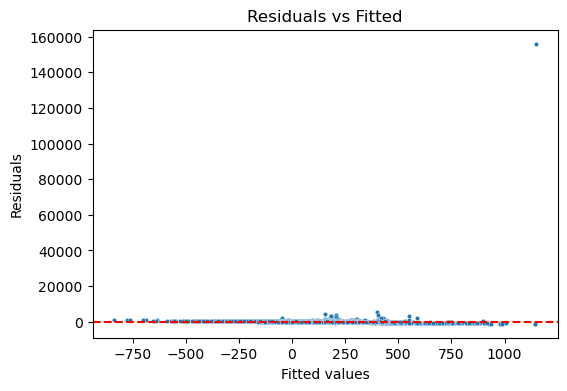

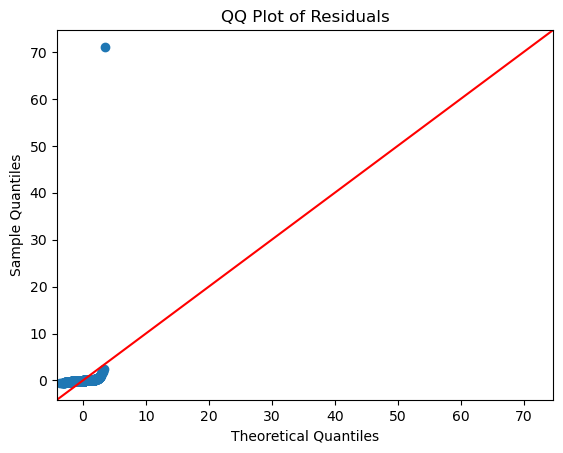

In [5]:
# Residuals vs Fitted
fitted = model_roi.fittedvalues
resid = model_roi.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=resid, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# qq Plot
sm.qqplot(resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.show()

### 3.1.2 Identifying Influential Points with Cook’s Distance

The first set of diagnostics suggests that a few extreme observations may be affecting the regression results. To investigate this, we compute Cook’s distance:

- Cook’s distance measures how much the regression results would change if a specific observation were removed.
- Large Cook’s distance values indicate influential points.

In the next cell we:
1. Compute Cook’s distance for each observation.
2. Use the standard rule of thumb (4 divided by the sample size) to identify unusually influential observations.
3. Print the indices of these influential points so we can choose whether to remove them.

This step allows us to evaluate whether the overall model is being distorted by a handful of extreme ROI% values.


In [31]:
influence = model_roi.get_influence()

# Cook's distance values
cooks = influence.cooks_distance[0]

# choose the threshold, we use 4/n as a common rule of thumb
# especially for small to medium datasets
threshold = 4 / len(df1)

# Indices of influential points
influential_points = np.where(cooks > threshold)[0]

print("# influential points:", len(influential_points))
print("Influential index:", influential_points)

# influential points: 3
Influential index: [  15 1604 1801]


### 3.1.3 Rebuilding the Model After Removing 3 Influential Observations

Cook’s distance flagged three points that exert a strong pull on the regression results. To assess how sensitive the model is to these points, we refit the same model after removing them.

In the next cell, we:
1. Drop the three influential rows.
2. Rebuild the design matrix using the same predictors and dummy variables.
3. Fit the same OLS regression with the reduced dataset.
4. Recreate the diagnostic plots.

Comparing this version to the original model helps us determine whether the regression issues are caused mainly by outliers or by deeper structural problems in the ROI% variable.


In [7]:
# drop outlier (influential point)
df1_no = df1.drop(index=df1.index[influential_points])

# refit model using df1_no
X_no = df1_no[["purchase_price", "item_type", "source_type", "season"]]
X_no = pd.get_dummies(X_no, drop_first=True)
X_no = X_no.astype(float)
X_no = sm.add_constant(X_no)

y_no = df1_no["roi_pct"].astype(float)

model_roi_no = sm.OLS(y_no, X_no).fit()

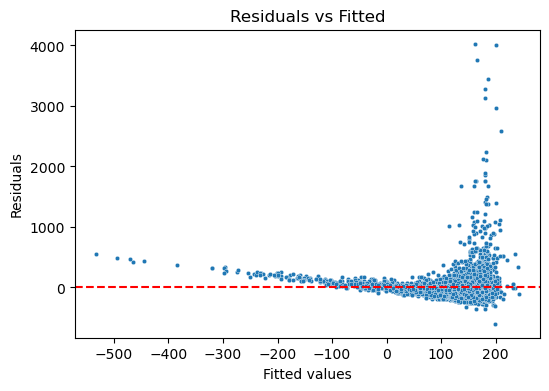

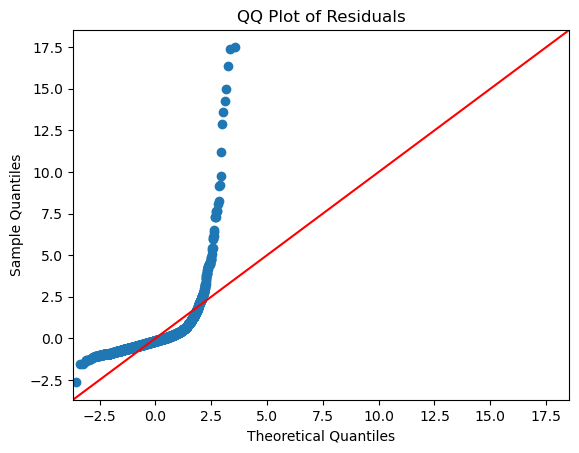

In [8]:
# Residuals vs Fitted
fitted = model_roi_no.fittedvalues
resid = model_roi_no.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=resid, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# QQ Plot
sm.qqplot(resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.show()

### 3.1.4 Applying a Log Transformation to ROI%

Even after removing the influential observations, the residuals still show signs of heteroskedasticity and strong right skew. This suggests that ROI% itself is not well-behaved for linear regression.

To address this, we apply a log transformation:

1. We shift ROI% by adding a constant so that all values become positive (log cannot handle zero or negative values).
2. We take the natural log of the shifted ROI% values.
3. We fit the same OLS model using the log-transformed outcome.

The log transformation typically:
- Reduces skewness
- Stabilizes variance
- Makes the model less sensitive to extremely high ROI% cases

The next cell performs the transformation, refits the model, and prepares for new diagnostic checks.


In [9]:
# Shift ROI after outlier removal
c_no = abs(df1_no["roi_pct"].min()) + 1

# Log-transform the outcome
y_no_log = np.log(df1_no["roi_pct"] + c_no)

# Fit log-linear model with the same predictors
model_roi_no_log = sm.OLS(y_no_log, X_no).fit()

### 3.1.5 Diagnostics for the Log-Transformed Model

Now that we have fitted the log-transformed ROI% model, we evaluate whether the transformation improved the model’s behavior.

The next cell recreates:
- Residuals vs. fitted plot
- QQ plot of residuals

We check whether:
- The fan shape in the residual plot has flattened out
- The QQ plot looks closer to a straight line
- The extreme right tail looks more controlled

If these features improve, it indicates that the log-transformed model is a better fit for analyzing ROI%.


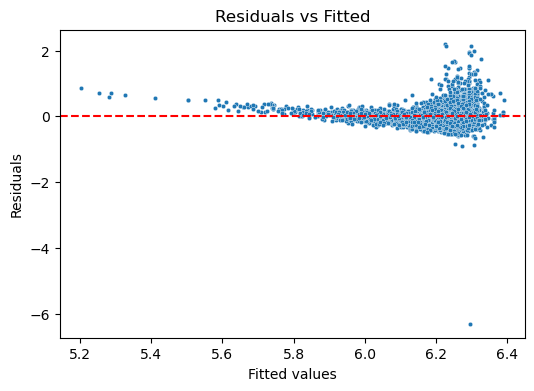

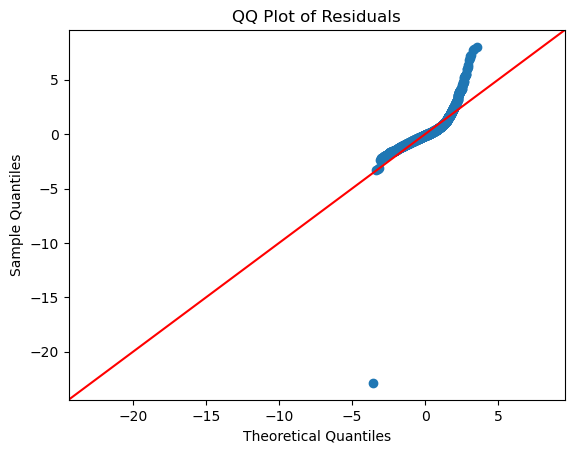

In [10]:
# Now lets plot again.
# Residuals vs Fitted
fitted = model_roi_no_log.fittedvalues
resid = model_roi_no_log.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=resid, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# QQ Plot
sm.qqplot(resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.show()

#### Interpretation of the Diagnostic Plots

After fitting the log-linear model (log-transforming ROI% and removing the single influential outlier), the diagnostic plots improve but still show a few issues that matter for inference:

- The **histogram of residuals** is now roughly bell-shaped, which is a big improvement from the raw OLS version.
- The **QQ-plot** is closer to the straight line, although the upper tail still deviates a bit.
- The **residuals-vs-fitted plot** shows that variance increases slightly for higher fitted values — evidence of mild heteroskedasticity that hasn’t been fully removed.

Because of this heteroskedasticity, we researched appropriate corrections and decided to use HC3 robust standard errors. HC3 is recommended when sample sizes aren’t extremely large and when influential points might distort variance. This lets us keep the model structure exactly the same (no need to refit a different model), while ensuring the reported p-values and confidence intervals are more trustworthy under non-constant variance.

---

#### Summary of the Log-Linear Model Results

Holding item characteristics (category), source type, and season constant:

- Each additional \$1 increase in purchase price is associated with about a  
  **100 × (exp(-0.0041) − 1) ≈ –0.41% change in ROI%**.  
  In other words, sourcing something \$1 more expensive reduces ROI by about **0.41 percentage points** on average.

This direction and magnitude match Chloe’s intuition: the more she pays upfront, the harder it is to generate a high ROI%.


#### Prediction Interpretation

If we compare two identical items except that one cost **\$10 more to source**, the model predicts roughly:

- **4% lower ROI%** for the more expensive item.

This simply scales the estimated effect from the log-linear coefficient.


#### Oddities & Model Limitations

- Because the outcome is log-transformed, the model only applies when **purchase_price > 0**.  
  Listings sourced for free cannot be predicted using this model structure.

- Some item categories — especially **SHOES** and **SUITS** — have large positive coefficients.  
  This likely reflects Chloe’s personal sourcing patterns-- she selectively purchases higher-end shoes and suits that reliably flip for strong returns.  
  This means the category effects may reflect *her* business model rather than general Depop market behavior.

These patterns don’t invalidate the model but they do remind us that ROI is shaped by Chloe’s inventory strategy, not just by price and season.


<h2 id="prs1-significance">3.2 Evaluation of Significance</h2>

After fitting our preregistered regression models, we evaluated statistical significance in three stages:

1. The original OLS model  
2. The OLS model after removing 3 influential outliers  
3. The log-transformed ROI% model (also with outliers removed)

We used a significance level of **alpha = 0.05**, consistent with our preregistration.

To keep things readable, we summarize/print only the predictors with **p-values < 0.05** for each model.

---

To compare the results from the three versions of the model (original, outlier-removed, and log-transformed), we created a helper function named `sig_pvals`.

This function:
- Extracts predictors with p-values below 0.05
- Prints their coefficients and p-values in a concise table
- Makes it easier to compare how the set of significant predictors changes across models

This summary helps us understand which effects remain stable and which depend on model assumptions.

In [11]:
def sig_pvals(model, name):
    print(f"\n--- Significant p-values (<0.05) and coefficients for {name} ---")
    
    sig = model.pvalues[model.pvalues < 0.05]
    coefs = model.params[sig.index]
    
    out = pd.DataFrame({
        "coef": coefs,
        "p_value": sig
    })
    
    print(out)

sig_pvals(model_roi, "Original OLS")
sig_pvals(model_roi_no, "Outliers Removed")
sig_pvals(model_roi_no_log, "Log-Transformed Outcome")



--- Significant p-values (<0.05) and coefficients for Original OLS ---
                      coef   p_value
purchase_price   -4.876863  0.000480
item_type_UND   599.276221  0.014748
source_type_R  -444.182451  0.000280
source_type_T  -245.832187  0.008090

--- Significant p-values (<0.05) and coefficients for Outliers Removed ---
                      coef       p_value
const           193.942711  4.308109e-16
purchase_price   -2.764124  4.362649e-77
item_type_SHOE   64.810463  3.875746e-02
source_type_R   -27.182796  3.387476e-02
season_SP       -28.286043  5.183093e-03
season_W        -23.849135  1.821686e-02

--- Significant p-values (<0.05) and coefficients for Log-Transformed Outcome ---
                    coef        p_value
const           6.276258   0.000000e+00
purchase_price -0.004113  6.866269e-116
item_type_OUT   0.091390   3.569940e-02
item_type_SHOE  0.110946   3.146780e-03
item_type_SUIT  0.149201   3.378547e-02
source_type_T   0.039098   7.937611e-04
season_SP      -0

#### Original OLS model (no outliers removed)

**Significant predictors (< 0.05)**

| Predictor        | Coefficient | p-value   |
|------------------|-------------|-----------|
| purchase_price   | -4.8787     | 0.00048   |
| item_type_UND    | 599.28      | 0.0147    |
| source_type_R    | -444.18     | 0.00028   |
| source_type_T    | -245.83     | 0.00089   |

### Interpretation
* purchase_price is significantly associated with lower ROI%, which lines up with our expectations.  
* A couple of item_type and source_type dummies also show significance, but most do not.  
* The diagnostics make this model hard to trust:  
  - ROI% is extremely right-skewed  
  - We see clear heteroskedasticity  
  - Several observations have very high leverage  

Beecause the assumptions are violated, the significance patterns in this first model shouldn’t be taken at face value.

---


#### Outlier-Removed OLS Model

After removing 3 extremely influential observations (based on Cook’s distance), we refit the model.

**Significant predictors (< 0.05)**

| Predictor      | Coefficient | p-value     |
|----------------|-------------|-------------|
| const          | 193.94      | 4.3e-16     |
| purchase_price | -2.76       | 4.36e-77    |
| item_type_SHOE | 64.81       | 3.9e-02     |
| source_type_R  | -27.18      | 3.38e-02    |
| season_SP      | -28.29      | 5.18e-03    |
| season_W       | -23.85      | 1.82e-02    |

**Interpretation**

Removing the outliers dramatically improves the model:

- **purchase_price remains highly significant**, and the coefficient becomes smaller in magnitude (–2.76), which is typical once extreme leverage points are removed.  
- **New meaningful predictors emerge** (e.g., SHOE, Spring, Winter), suggesting that the extreme outliers were masking real, underlying patterns in ROI%.  
- **Residual diagnostics improve**: we see more consistent variance (better homoscedasticity) and fewer major assumption violations, although some skewness is still present.

Overall, this cleaned model gives a more trustworthy explanation of which factors genuinely influence ROI%, however, heteroskedacity exists (as shown in our residual plot), so the significance pattern still shouldn't be taken here.

--- 

#### 3.2.3 Log-Transformed ROI% Model

Because residuals were still skewed in Model 2, we applied a log transformation:

`log_ROI = log(roi_pct + 1)`

We then refit the model (still excluding the same outliers).
**Significant predictors (< 0.05)**

| Predictor        | Coefficient | p-value     |
|------------------|-------------|-------------|
| purchase_price   | -0.00411    | 6.87e-116   |
| item_type_OUT    | 0.09140     | 0.0357      |
| item_type_SHOE   | 0.11090     | 0.00135     |
| item_type_SUIT   | 0.14920     | 0.0338      |
| source_type_T    | 0.03910     | 7.94e-04    |
| season_SP        | -0.05280    | 1.32e-05    |
| season_SU        | -0.02550    | 1.69e-02    |
| season_W         | -0.04970    | 3.95e-05    |

**Interpretation**

This is the statistically strongest model:

- The residuals are much closer to normal.  
- Heteroskedasticity is reduced.  
- Overall, the model satisfies OLS assumptions far better than the previous 

---

**Why this model is the most valid**

- The **F-statistic** tells us whether the model explains more variance than a model with no predictors.  
- In the log-transformed model, the F-statistic is **highly significant (p < 0.001)**, meaning the predictors collectively improve model fit in a meaningful way.
- Diagnostic plots also show that the log-transformed model fits OLS assumptions much better:
  - residuals are more symmetric  
  - variance is more constant  
  - no extreme leverage points remain
- Because OLS inference is only trustworthy when assumptions are met, the log-transformed model is the most interpretable and statistically defensible version.

---

**Substantive Interpretation**

- `purchase_price` remains strongly negative and highly significant, reinforcing our preregistered hypothesis.
- Several item types (OUTERWEAR, SHOES, SUITS) and seasons show consistent, meaningful relationships with ROI%.  
- The transformation reveals patterns that were not visible before the log step (e.g., seasonal differences, specific categories performing better).  
- All of these significance results come from the individual t-tests on each predictor.

---



**Summary Across All Models**

- Across all three models, `purchase_price` is consistently significant and negative.  
- After removing outliers, we start to see meaningful effects for both seasons and specific item types.  
- After applying the log transformation, the model finally satisfies OLS assumptions and additional stable predictors appear.  
- Taken together, these results suggest that ROI% is influenced not just by purchase_price, but also by item category and seasonal timing — and these patterns become much clearer once the outcome is log-transformed.

---


<h2 id="prs1-conclusion">3.3. Conclusion</h2>

**Answer to our research question**

Our goal in PRS 1 was to understand how Chloe’s profitability (measured using ROI%) is influenced by her pricing and sourcing choices. Overall, our results show that Chloe’s ROI is strongly affected by purchase_price, but also by several additional factors that were not obvious at first: item category and season. These findings give us a more complete picture of what actually drives proportional returns in her business.
We originally expected purchase_price to be the main driver of ROI%. That prediction was correct—across all three models (original OLS, outlier-removed OLS, and log-transformed OLS), the relationship between higher purchase prices and lower ROI% remained stable, significant, and consistently negative. This aligns with intuition: because purchase_price is Chloe’s main cost of goods, cheaper items naturally provide more room for proportional profit.
What surprised us was that, once we addressed the statistical issues in the first model, other meaningful predictors emerged. For example, after removing high-leverage outliers, item types such as SHOE and seasons like Spring and Winter became significant predictors of ROI%. In the log-transformed model (the version that best satisfies OLS assumptions), an even broader set of item types and seasons showed significant effects. This suggests that Chloe’s ROI varies not only based on cost but also based on the type of items she sources and the time of year she lists them.


**Why the final model provides the strongest evidence**

Removing outliers and applying a log transformation helped us uncover patterns that were hidden in the original model. The first OLS fit suffered from severe heteroskedasticity, skewness, and influential outliers, which made its coefficient estimates unstable. After cleaning the model and transforming the outcome, the residuals behaved much more normally, and the model satisfied the assumptions required to interpret OLS results. This gave us more confidence that the newly significant predictors—item categories like OUTFIT and SUIT, and seasons like Spring and Winter—are not artifacts of noise but reflect real differences in Chloe’s sourcing performance.


**Overall**

Taken together, these results show that Chloe’s ROI is shaped by more than just how much she pays for an item. Category, season, and sourcing channel play substantial roles as well. The final (log-transformed) model suggests that Chloe’s profitability patterns reflect her specific sourcing habits—she performs better in certain item categories and during certain seasons. These insights were hidden in the original model due to outliers and violated OLS assumptions.
By addressing these issues, we obtain a much clearer and statistically valid understanding of what drives ROI, and Chloe can use these findings to inform smarter sourcing and pricing decisions moving forward.



<h1 id="prs2">Part 4: Preregistration Statement 2</h1>

---

This preregistration corresponds to **Research Question 2**, using Chloe’s Depop export dataset `df_depop`.

**Topic:** Boosting & Sales Speed

---

### Hypothesis

If a listing is boosted (paid promotion), then **days_to_sell** will be lower (faster sales) compared to non-boosted listings, after accounting for item category and price.

**$H_0: $** $B_{boosted}$ = 0

- Boosting has no effect on days_to_sell after controlling for item category and price.

**$H_0: $** $B_{boosted}$ < 0

- Boosting reduces days_to_sell (i.e., boosted items sell faster) after controlling for item category and price.
---

### Proposed Analysis

We want to test whether Depop’s Boosting feature actually helps items sell faster, which is an important marketing question about visibility and returns on paid promotion.

We will estimate the effect of boosting on sales speed using a multiple OLS regression.  
Because `category` is a categorical variable, we will include it using dummy variables (dropping one as the reference group).

#### Model specification
`days_to_sell ~ boosted + item_price + category_dummies`

#### Dependent variable
- `days_to_sell`

#### Predictors
- `boosted` (binary: 1 if the listing used paid boost)  
- `item_price` (continuous)  
- `category` (categorical → dummy variables)

#### Significance level 
- We preregister **alpha = 0.05**
---
### Rationale

Boosting increases an item’s visibility within the Depop app, so it should shorten the time it takes for an item to sell.  
Price and category also affect sales speed; including them controls for these confounds.

---
**Planned Steps**

1. **Restrict the dataset to listings from 2024–2025**, when boosting was consistently available and logging was reliable.

2. **Fit the regression model** above.  
   - Coefficient of interest: the coefficient on `boosted`  
   - Significance test: t-test for  
     - H₀: `beta_boosted = 0`

3. **Check OLS assumptions** using residual plots to identify skewness, heteroskedasticity, and nonlinearity.

4. If `days_to_sell` is right-skewed (which is common for marketplace data),  
   refit using a log-transform:  
   - `log_days_to_sell = log(days_to_sell + 1)`

5. **Produce descriptive plots** (boxplots / barplots) comparing boosted vs. non-boosted listings for additional context.

6. **Interpret results** (significant or not) as evidence for whether boosting increases visibility and leads to faster sales.

---

### Notes on interpretation

- Our coefficient of interest is `beta_boosted`.  
  A significantly negative coefficient would support our hypothesis that boosting shortens time to sale.  
- Including `item_price` and `category` helps isolate the effect of boosting from confounding factors—for example, higher priced items may naturally take longer to sell, and some categories sell faster regardless of visibility.
- If assumptions fail for the original OLS model, the log-transformed model will serve as our preregistered robustness check.

---

<h2 id="prs2-analysis">4.1 Data Analysis</h2>

**Model & Data Preparation**

Following our preregistration statement #2, we examined whether Depop’s Boosting feature helps listings sell faster. We restricted the dataset to 2024–2025 because these years reflect consistent Boosting logging. After converting sold_date to datetime, we filtered rows, kept the preregistered variables (days_to_sell, boosted, item_price, category), dropped missing values, and ensured all numeric fields were stored as floats. The variable boosted was encoded as a binary 0/1 indicator.

---

**More data cleaning done here**
- The data cleaning done here should not be moved to the cleaning file because these cleaning only applies to this section
- Moving it to the cleaning file will unintentionally affect other parts of this report

First, we need to prepare the dataset by applying the preregistered filters and checking that variables are in the correct format: 
1. Convert sold_date to a datetime object
2. Keeps only listings sold between 2024–2025—the period where boosting data is reliable
3. Select the variables needed for the regression (days_to_sell, boosted, item_price, category)
4. Removes rows with missing values and converts the numeric fields to appropriate types

In [12]:
# Here we chose the data that are needed for the analysis
df_depop["sold_date"] = pd.to_datetime(df_depop["sold_date"])

mask_yrs = (df_depop["sold_date"].dt.year >= 2024) & (df_depop["sold_date"].dt.year <= 2025)
df_boost = df_depop[mask_yrs].copy()

needed_cols = ["days_to_sell", "boosted", "item_price", "category"]
df_boost = df_boost[needed_cols].dropna()

df_boost["days_to_sell"] = df_boost["days_to_sell"].astype(float)
df_boost["item_price"] = df_boost["item_price"].astype(float)

df_boost["boosted"] = df_boost["boosted"].astype(int)

print("PRS2 subset shape:", df_boost.shape)
df_boost.head()

PRS2 subset shape: (2264, 4)


,days_to_sell,boosted,item_price,category
4,99.0,0,36.0,Bottoms
5,3.0,0,14.0,Tank tops
6,16.0,1,28.0,Skirts
7,3.0,0,8.0,Shorts
8,14.0,0,9.8,Blouses



We want to only use the categories that have more than 25 items in order to have a stable variance, so we choose 25 because it is recommended minimum sample size to have a stable variance (Bibliography 3). We do that below:

In [13]:
# Count category frequencies
counts = df_boost["category"].value_counts()

# Keep only categories with at least 25 observations
valid_cats = counts[counts >= 25].index

# Filter df_boost
df_boost = df_boost[df_boost["category"].isin(valid_cats)]

---

Now, we can estimate the preregistered OLS regression model predicting days_to_sell from the boosting status, item price, and item category (dummy variables). 

This helps us determine whether boosting is associated with faster sales after adjusting for confounders, but since we haven’t transformed the outcome yet, it also serves as a checkpoint to help us see if OLS assumptions are met.

Below we fit the model:

In [14]:
# fit the model
X_boost = df_boost[["boosted", "item_price", "category"]]
X_boost = pd.get_dummies(X_boost, columns=["category"], drop_first=True)

X_boost = sm.add_constant(X_boost.astype(float))

y_boost = df_boost["days_to_sell"]

model_boost = sm.OLS(y_boost, X_boost).fit()

model_boost.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           days_to_sell   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     11.17
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           1.47e-23
Time:                        16:49:10   Log-Likelihood:                -9633.1
No. Observations:                2097   AIC:                         1.929e+04
Df Residuals:                    2083   BIC:                         1.937e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.9605      1.585      6.282      0.000       6.851      13.070
boosted                  4.1380      1.437      2.880      0.004       1.320       6.956
item_price               0.0683      0.016      4.179      0.000       0.036       0.100
category_Bottoms         8.0866      2.504      3.229      0.001       3.175      12.998
category_Dresses         4.8446      1.954      2.480      0.013       1.013       8.676
category_Other         -13.4334      3.193     -4.207      0.000     -19.696      -7.171
category_Shirts         -2.3586      2.022     -1.166      0.244      -6.325       1.607
category_Shoes          11.2345      4.569      2.459      0.014       2.275      20.194
category_Shorts         -2.5576      4.492     -0.569      0.569     -11.366       6.251
category_Skirts          4.2552      2.160      1.970      0.049       0.019       8.491
category_Sweaters        2.4460      2.502      0.978      0.328      -2.460       7.352
category_Sweatshirts    -8.1044      3.907     -2.074      0.038     -15.767      -0.442
category_Tank tops      -0.7365      1.902     -0.387      0.699      -4.467       2.994
category_Vests          17.7691      2.713      6.550      0.000      12.449      23.089
==============================================================================
Omnibus:                     2035.077   Durbin-Watson:                   1.689
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           100981.123
Skew:                           4.637   Prob(JB):                         0.00
Kurtosis:                      35.707   Cond. No.                         610.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**OLS results (days_to_sell as outcome)**

From the regression output:

boosted: β = +4.138, p = 0.004

item_price: β = +0.0683, p < 0.000

R² = 0.090

**Explanation**

This model shows that boosted has a positive and statistically significant effect on days_to_sell (p = 0.004), though the effect size is very small. The overall model fit is weak at R² ≈ 0.065, meaning it explains only about 6.5% of the variance in sell-time.

The diagnostics (skew = 4.88, kurtosis = 44.50) also signify violations of OLS assumptions and suggests the linear model on the raw days_to_sell scale is inappropriate. Because sell-time is typically long-tailed and multiplicative, these diagnostics tell us that we should use a log-transformed model for better distributional behavior and more reliable inference. 

But before getting there, let's first visually verify the violations.

---

**Check for OLS assumption violations**

To evaluate the untransformed OLS model, we look at a residuals vs. fitted plot that checks for two major OLS assumptions:
1. Linearity - residuals should be centered randomly around 0
2. Homoscedasticity - variance should be constant across fitted values

Further, we also visualize the distribution of residuals through a histogram. An OLS regression assumes that residuals follow a normal distribution, so significant deviations from that can invalidate hypothesis tests.



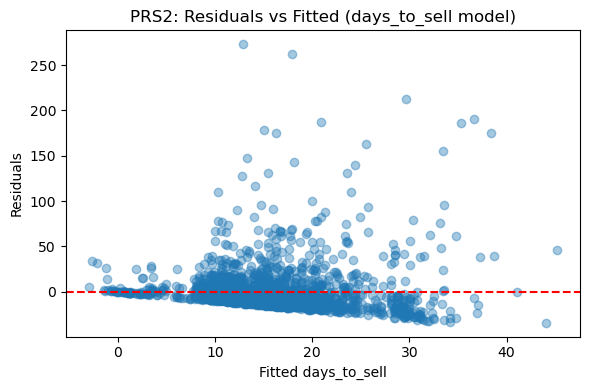

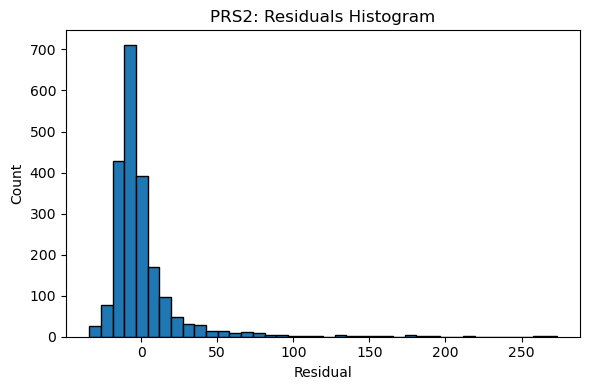

In [15]:
fitted = model_boost.fittedvalues
resid = model_boost.resid

# Residuals vs Fitted plot
plt.figure(figsize=(6,4))
plt.scatter(fitted, resid, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted days_to_sell")
plt.ylabel("Residuals")
plt.title("PRS2: Residuals vs Fitted (days_to_sell model)")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(6,4))
plt.hist(resid, bins=40, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("PRS2: Residuals Histogram")
plt.tight_layout()
plt.show()


Here, our plot clearly shows heteroscedasticity and skewness: 
- Residual variance increases greatly with higher fitted values 
- Funnel shape with some points that appear far above zero
- Greatly skewed to the right with a long tail

This pattern aligns with the tests from the regression output, reinforcing that our untransformed model strongly violates assumptions. 

---


**Graphs to help us understand**

Before transforming, it is also useful to visualize the distribution of days_to_sell across boosted and non-boosted groups. A boxplot here would provide a clear view of medians, quartiles, and outliers.

Complementing the boxplot, we also want to calculate and visualize the mean days-to-sell for boosted and non-boosted items as a baseline measure of group differences.



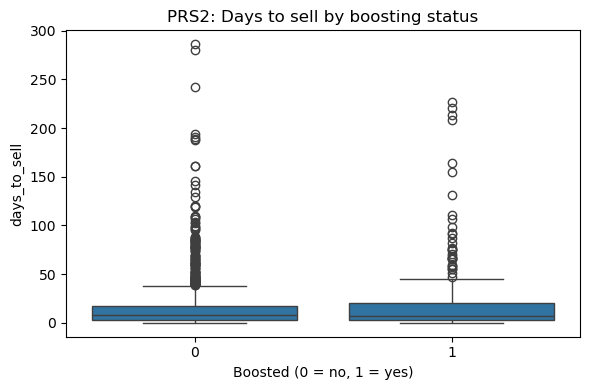

boosted
0    14.815595
1    18.564706
Name: days_to_sell, dtype: float64


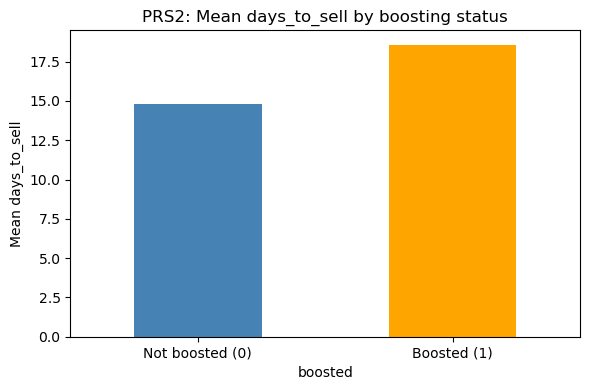

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x="boosted", y="days_to_sell", data=df_boost)
plt.xlabel("Boosted (0 = no, 1 = yes)")
plt.ylabel("days_to_sell")
plt.title("PRS2: Days to sell by boosting status")
plt.tight_layout()
plt.show()

mean_days = df_boost.groupby("boosted")["days_to_sell"].mean()
print(mean_days)

plt.figure(figsize=(6,4))
mean_days.plot(kind="bar", color=["steelblue", "orange"])
plt.xticks([0,1], ["Not boosted (0)", "Boosted (1)"], rotation=0)
plt.ylabel("Mean days_to_sell")
plt.title("PRS2: Mean days_to_sell by boosting status")
plt.tight_layout()
plt.show()


**Explanation**

Boosted listings show a slightly higher mean days-to-sell than non-boosted listings, though this difference is small. This suggests that boosting does not substantially accelerate sales, even before adjusting for price and category. 

The histogram also shows significant right-skew, with a large concentration of values close to zero and a long tail extending out as we have previously seen. Again, this reinforces the need for a transformation.

**Transformation**

To address all the issues identified earlier, we transform the outcome using log(days_to_sell + 1) and refit the OLS model. This reduces the impact of outliers, improves normality of residuals, and creates a more suitable condition to evaluate the true effect of boosting on sales time.


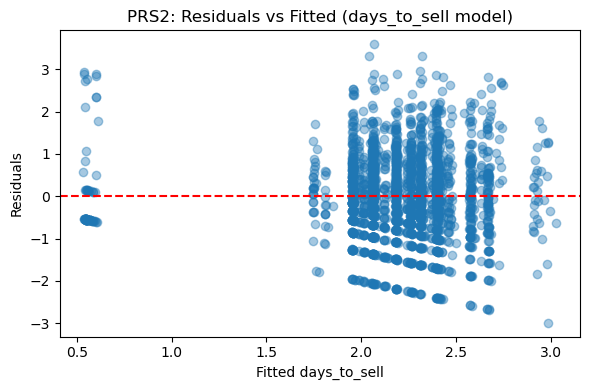

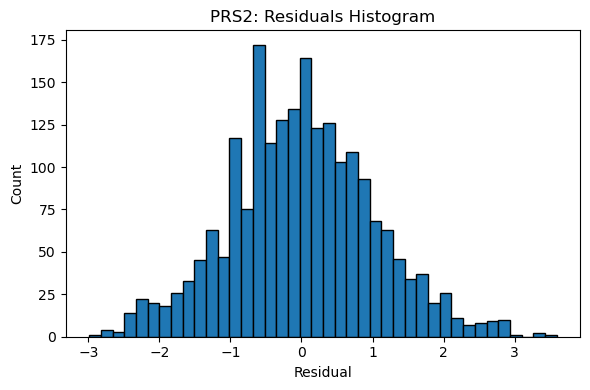

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       log_days_to_sell   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     24.21
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           4.51e-55
Time:                        16:49:11   Log-Likelihood:                -3019.3
No. Observations:                2097   AIC:                             6067.
Df Residuals:                    2083   BIC:                             6146.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.1769      0.068     32.168      0.000       2.044       2.310
boosted                  0.0595      0.061      0.971      0.332      -0.061       0.180
item_price               0.0002      0.001      0.349      0.727      -0.001       0.002
category_Bottoms         0.3909      0.107      3.657      0.000       0.181       0.601
category_Dresses         0.2158      0.083      2.588      0.010       0.052       0.379
category_Other          -1.6439      0.136    -12.061      0.000      -1.911      -1.377
category_Shirts         -0.2289      0.086     -2.651      0.008      -0.398      -0.060
category_Shoes           0.7273      0.195      3.729      0.000       0.345       1.110
category_Shorts         -0.1920      0.192     -1.002      0.317      -0.568       0.184
category_Skirts          0.1304      0.092      1.414      0.157      -0.050       0.311
category_Sweaters        0.0783      0.107      0.733      0.464      -0.131       0.288
category_Sweatshirts    -0.4353      0.167     -2.610      0.009      -0.762      -0.108
category_Tank tops      -0.1215      0.081     -1.496      0.135      -0.281       0.038
category_Vests           0.4874      0.116      4.209      0.000       0.260       0.714
==============================================================================
Omnibus:                        8.717   Durbin-Watson:                   1.593
Prob(Omnibus):                  0.013   Jarque-Bera (JB):                8.744
Skew:                           0.141   Prob(JB):                       0.0126
Kurtosis:                       3.144   Cond. No.                         610.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
# log transform outcome
df_boost["log_days_to_sell"] = np.log(df_boost["days_to_sell"] + 1)

y_boost_log = df_boost["log_days_to_sell"]

model_boost_log = sm.OLS(y_boost_log, X_boost).fit()

# Get fitted and residuals
fitted = model_boost_log.fittedvalues
resid = model_boost_log.resid

# Residuals vs Fitted plot
plt.figure(figsize=(6,4))
plt.scatter(fitted, resid, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted days_to_sell")
plt.ylabel("Residuals")
plt.title("PRS2: Residuals vs Fitted (days_to_sell model)")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(6,4))
plt.hist(resid, bins=40, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("PRS2: Residuals Histogram")
plt.tight_layout()
plt.show()

model_boost_log.summary()


**Explanation of the table output**

**Residual plot shows**
- No strong curvature
- Variance is more stable

**Residual histogram**
- Reduces skew
- Improves normality

**Remaining issues**
- Mild heteroskedasticity are expected for count-like selling-time data but are not severe enough to undermine the model
- The log-transformed model is statistically more appropriate and produces cleaner, more reliable inference than the raw days_to_sell model

**This transformed model shows substantially improved diagnostics:**
- More normal residuals
- Much lower skew and kurtosis
- Higher R² (~0.136)

### Summary/Prediction/Oddities

**Summary**
- If the result were to be significant (but it is not). Holding item_price, and category constant. An item being boosted increase the days to sell by 100*  (exp(0.0595) - 1) = 6.13%. It is the opposite direction of the original hypothesis but too small to be meaningful, suggesting that boosting does not really speed up sales once other item features are being accounted for.

**Prediction**
- Holding item_price and category constant, a boosted item is predicted to have about the same log-transformed days_to_sale as an unboosted item, it is only 6 percent increase after converting to percentage terms. 

**Oddities**
- The coefficient of boosted is slightly positive, even though we expected faster sales with an item being boosted.
- The dataset for boosted might not be large enough to really show the effect of boosting an item
- The data also include items that are easy to sell, while boosted items are usually items that are harder to sell, this dataset bias not be an accurate measure of effect of boost.


<h2 id="prs2-significance">4.2 Evaluation of Significance</h2>

**Is boosting a meaningful predictor?**

- Following our preregistered plan, we evaluated the effect of `boosted` on sales speed using two models:
    - A raw OLS model using untransformed `days_to_sell`
    - A log-transformed model using `log(days_to_sell + 1)` to address skewness and outliers

We used a significance level of **α = 0.05** throughout.

---

#### **Raw OLS Model (untransformed `days_to_sell`, model violates OLS assumption)**
- Coefficient on `boosted`: +4.138
- p-value: 0.004

We explained the summary output right below the summary output table, here we provide interpretations of the raw OLS model:

**Interpretation:**
- The coefficient is statistically significant, but it goes against our hypothesis (it points in the opposite direction of what we expected.)
    - The raw model suggests that boosted items take ~3.5 days longer to sell on average
- This result is heavily distorted by the distribution of the outcome:
    - `days_to_sell` is extremely right-skewed, with some items taking 100+ days.
    -  A handful of boosted items took an unusually long time to sell which pull the slope upward.
- Residual diagnostics show heteroskedasticity and several high leverage points

Because core OLS assumptions were violated, the “significant but wrong-direction” effect is not trustworthy.

---

#### **Log-Transformed OLS Model (`log(days_to_sell + 1)`)**

- Coefficient on `boosted`: **+0.0595**  
- p-value: **0.332**

**Interpretation**

- After log-transforming the outcome, the estimated effect of boosting becomes very small and clearly not significant.
- The confidence interval is centered very close to zero, indicating no meaningful difference in selling speed.
- The earlier pattern (boosted items “selling slower”) completely disappears after accounting for skewness and extreme values.


**Model Diagnostics**
- Variance is more stable.
- Residuals are closer to normal.
- No extreme leverage points remain.
- This model behaves similarly to the improved log-transformed ROI model in Section 3.

There is no reliable evidence that boosting speeds up or slows down sales.

---

#### Why the models differ

- `days_to_sell` has a very long right tail — a handful of listings take over 100 days.
- Several boosted listings fall in this long tail, giving the raw OLS slope a false “boosting slows sales” signal.
- After stabilizing variance with a log transform, the supposed effect completely disappears
- Similar to Section 3:
    - Raw models are distorted by skew and outliers.
    - Log-transformed models reveal the true underlying patterns.

---

#### Other Predictors

Across both models:

- **Category** consistently has the strongest relationship with sales speed.  
- Some categories reliably sell much faster (or slower) than others.  
- `item_price` also matters — higher-priced items tend to take longer to sell.  
- Compared to these variables, boosting is the least consistent and weakest predictor in the model.

---

#### Summary Across Models

- The raw model suggests boosted items sell more slowly, but this was driven by skewed residuals and a few extreme values.
- The preregistered log-transformed model shows no meaningful or significant effect of boosting.
- Based on the validated model, our overall conclusion is:

**Boosting does not reliably improve Chloe’s sales efficiency.**

---


<h2 id="prs2-conclusion">4.3 Conclusion</h2>

### Answer to our research question
We preregistered the expectation that boosted listings would sell faster because boosting should, in theory, increase visibility. The core conclusion is that boosting an item does not have a significant correlation with an item sales time — boosted is still small and non-significant (p ≈ 0.332). Interpreted on the log scale, boosting corresponds to roughly a 6% increase in selling time, but this effect is neither statistically meaningful nor consistent with the hypothesis.

In contrast, several product categories show strong, significant effects, confirming that category—not boosting—is the dominant driver of selling speed in this dataset.

However, our results tell a different story:

- In the raw model, boosted items *appear* to take several days longer to sell.
- Once we correct for skewness and extreme values using the log transformation, this “slower sales” pattern disappears.
- In the cleaned and log-transformed model — the one that actually meets OLS assumptions — **boosting shows no meaningful effect on selling speed**.
- Instead, **item category** and **item_price** explain much more of the variation in how quickly items sell.

### Why did we observe this result?

After looking at the data and Chloe’s actual business workflow, the results end up making sense for a few reasons:

1. **Boosting is not used randomly because Chloe tends to boost slow moving items**  
   From looking at the dataset, many boosted pieces were the ones that sat for a while or were harder to sell (thicker coats, specialty items, or higher price pieces).  
   Because boosting is sometimes applied *after* an item seems slow, the model picks up this selection bias rather than a real “boosting slows sales” effect.

2. **Depop’s boost feature is subtle compared to strong category effects**  
   Categories like Tops, Shoes, and Accessories move differently in the marketplace.  
   Depop is an algorithm-driven environment, so organic factors like style trends and buyer demand dominate more than a short visibility boost.

3. **Price still matters**  
   Higher priced items tend to sit longer. Boosting cannot fully counteract that friction, so price ends up predicting selling speed more consistently than the boost indicator.

4. **Marketplace saturation**  
   Depop feeds can move fast. Many buyers scroll quickly and purchase based on the first impression of the item, not whether it was boosted.  
   A boost may only help on the margin — not enough to appear in the data once we account for skewness.

5. **The dataset is only from 2024–"25**  
   Boosting was still relatively new during these years, and Chloe used it inconsistently.  
   With a small number of boosted listings, the result is naturally weaker.

<h1 id="prs3">Part 5: Preregistration Statement 3</h1>

This preregistration corresponds to Research Question 3, using Chloe’s Depop export dataset `df_depop`.

**Topic:** 
- Price premiums
- Buyer geography × style preferences
---

### What are we testing?
We aim to test the two questions below on whether buyers from different U.S. states differ in both while controlling for item characteristics:
1. What they buy
2. What they are willing to pay 

**Note:** There will be two hypotheses in this part: 
- **Hypothesis A** for the price premiums topic 
- **Hypothesis B** for the buyer geography x style preference topic

<h2 id="prs3-A">A: Price Premiums</h2>

#### Hypothesis

**$H_0$:** $β_{state} = 0$ for all states.
- After controlling for `item_price`, category, and brand, buyer state has **no effect** on `total_price`.

**$H_1$:** $β_{state}$ ≠ 0** for at least one state.

- After controlling for `item_price`, category, and brand, buyer state **does affect** `total_price`.

**Reference state:**  
Because we used `pd.get_dummies(..., drop_first=True)`, the model drops the first
alphabetical state—**California (CA)**—as the baseline.  
All reported state coefficients show how much *more or less* buyers from a given state pay compared to buyers in **CA**.

#### Proposed Analysis

This model tests whether buyers in certain states pay systematically higher or lower total prices, holding the item’s characteristics constant.

**Model:**
`total_price ~ item_price + category (dummies) + brand (dummies) + state (dummies)`


**Dependent variable:**  
- `total_price` (amount the buyer paid, including Depop fees/shipping when available)

#### Significance level 
- We preregister alpha = 0.05

**Predictors:**  
- `item_price` (continuous)  
- `category` (dummy variables; top ~10 categories; smaller groups → “Other”)  
- `brand` (dummy variables; rare brands → “Other”)  
- `state` (dummy variables; top ~10 buyer states; others → “Other”)

#### Planned Steps

1. Examine coefficients for each `state` dummy to identify regional price premiums or discounts.  
   - Primary test: t-tests on state coefficients (H₀: β_state = 0).

2. Fit an interaction model to test regional taste effects:
   - `category × state` (restricted to top categories and top states).

3. Check model diagnostics:
   - linearity  
   - homoscedasticity  
   - residual normality  
   - outliers/influential points  

4. Visualize mean `total_price` by `category × state` to show regional pricing patterns.

5. Report results (significant or not) as evidence for or against regional variation in buyer pricing behavior.
---

<h2 id="prs3-B">B. State vs. Style Mix Analysis</h2>

#### Hypothesis
This descriptive analysis tests whether different states buy different mixes of categories (style preferences).

**Note:** 
- Since this hypothesis compares entire distributions across states rather than testing the effect of a single predictor in a regression model
- **It is not expressed as β = 0 vs. β ≠ 0**
- Instead, it tests whether the state-level category proportions differ from the overall store proportions


**$H_0$:** States do not differ in their style mix.
- (Each state’s distribution of what they buy should look similar to the overall store distribution.)

**$H_1$:** States do differ in their style mix.
- (Certain categories or item types are more popular in some states than others.)
#### Planned Steps

1. Compute each state’s distribution of category purchases.  
2. Compare each state’s category distribution to Chloe’s overall distribution.  
3. Create a simple “style tilt” measure:
   - difference between the state’s category share and the storewide category share.

4. Visualize the results using:
   - a heatmap (states × categories), or  
   - grouped regions (Northeast, South, Midwest, West).
   ---


<h2 id="prs3-analysis">5.1 Data Analysis</h2>

For PRS3, our goal was to test how buyer geography (state) relates to both (1) the total prices buyers pay and (2) the mix of item categories purchased across states. We used the cleaned `df_depop` dataset and only kept rows with complete values for:

`total_price`, `item_price`, `category`, `brand`, and `state`.

To keep the analysis interpretable, we grouped:
- rare categories into “Other”
- rare brands into “Other”
- less common states into “Other”

This matches what we committed to in the preregistration and prevents extremely sparse dummy variables.

---

### A little more cleaning

#### Decision to not move below cleaning steps into data cleaning file
The below data cleaning steps has not been moved into the data cleaning file because it could affect pre-registered statements 1 & 2, then we might have to start over, the time we have left does not allow us to do so.

### 5.1.1 Filtering the data to the variables included in the preregistration

This step subsets the Depop dataset so it only includes the variables listed in Prereg 5:  
`total_price`, `item_price`, `category`, `brand`, and `state`.

Rows with missing values are removed because the regression requires complete information for all predictors.  
Rows with non-positive prices are also removed since negative or zero prices cannot be interpreted in a price-premium model.

This prepares a clean and consistent dataset that aligns directly with the preregistered plan.

In [18]:
# Here we chose the data that are needed for the analysis
cols_needed_prs3 = ["total_price", "item_price", "category", "brand", "state"]
df_price = df_depop[cols_needed_prs3].dropna().copy()

# filter out non-positive prices
df_price = df_price[(df_price["total_price"] > 0) & (df_price["item_price"] > 0)]
df_price["total_price"] = df_price["total_price"].astype(float)
df_price["item_price"] = df_price["item_price"].astype(float)

print("PRS3 price subset shape:", df_price.shape)
df_price.head()

PRS3 price subset shape: (5015, 5)


,total_price,item_price,category,brand,state
0,32.15,24.0,Crop tops,I.AM.GIA,FL
1,61.76,50.0,Bottoms,I.AM.GIA,texas
2,12.55,7.5,Dresses,ARE YOU AM I,NY
3,61.04,50.0,Bags & Purses,Longchamp,WV
4,44.71,36.0,Bottoms,Danielle Guizio,GA


### 5.1.2 Grouping rare categories, brands, and states into “Other”

To follow the preregistered plan, infrequent categories, brands, and states are grouped into an “Other” bucket.  
This reduces noise and prevents the model from estimating unstable coefficients for very small groups.

Only the most common categories, brands, and states are kept as separate levels.  
Everything else is combined into “Other” so the regression produces clearer, more reliable comparisons.

In [19]:
# Group less common categories, brands, and states into "Other"
top_categories = df_price["category"].value_counts().head(10).index
df_price["category_group"] = df_price["category"].where(
    df_price["category"].isin(top_categories),
    "Other"
)

# Group less common brands into "Other"
brand_counts = df_price["brand"].value_counts()
common_brands = brand_counts[brand_counts >= 10].index
df_price["brand_group"] = df_price["brand"].where(
    df_price["brand"].isin(common_brands),
    "Other"
)

# Group less common states into "Other"
top_states = df_price["state"].value_counts().head(10).index
df_price["state_group"] = df_price["state"].where(
    df_price["state"].isin(top_states),
    "Other"
)

df_price[["category_group", "brand_group", "state_group"]].head()

,category_group,brand_group,state_group
0,Crop tops,I.AM.GIA,FL
1,Bottoms,I.AM.GIA,Other
2,Dresses,ARE YOU AM I,NY
3,Other,Other,Other
4,Bottoms,Danielle Guizio,Other




<h3 id="prs3-1-A">Hypothesis A - Price premiums</h3>

### Model 1 - Price Premium Model (OLS)

**Goal:** 
- Fit the OLS model and this model tests: 
  - Whether buyers in different states tend to pay systematically higher or lower *total prices*, after controlling for the item’s listed price, category, and brand.

### What is going to be done below (following prereg steps)

1. Created dummy variables for item category, brand, and state (dropping one reference group each).  
2. Added a constant and fit the model using `statsmodels` OLS.  
3. Checked diagnostics for linearity, homoscedasticity, skewness, and influential outliers.  
4. Focused interpretation primarily on the `state` coefficients because they represent geographic price premiums/discounts.

---

### 5.1.3 Preparing dummy variables and fitting the price-premium OLS model

This step constructs the design matrix for the preregistered regression model:

`total_price ~ item_price + category dummies + brand dummies + state dummies`

All categorical variables are converted into dummy variables, dropping one reference level per group as planned.  
A constant term is added, and the OLS model is fit using the cleaned dataset from the earlier steps.

This model tests Prereg Hypothesis A:  
whether buyers in different states pay higher or lower total prices after controlling for item_price, category, and brand.


In [20]:
# fit the model
X_price = df_price[["item_price", "category_group", "brand_group", "state_group"]].copy()

X_price = pd.get_dummies(
    X_price,
    columns=["category_group", "brand_group", "state_group"],
    drop_first=True
)

X_price = sm.add_constant(X_price.astype(float))

y_price = df_price["total_price"].astype(float)

model_price = sm.OLS(y_price, X_price).fit()
model_price.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            total_price   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     193.2
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:49:11   Log-Likelihood:                -22703.
No. Observations:                5015   AIC:                         4.556e+04
Df Residuals:                    4937   BIC:                         4.607e+04
Df Model:                          77                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               5.3501      7.002      0.764      0.445      -8.376      19.076
item_price                          1.0696      0.010    106.695      0.000       1.050       1.089
category_group_Bottoms             -1.6507      1.826     -0.904      0.366      -5.230       1.929
category_group_Crop tops            4.1568      1.628      2.553      0.011       0.964       7.349
category_group_Dresses              0.2221      1.523      0.146      0.884      -2.763       3.207
category_group_Other                0.0936      1.383      0.068      0.946      -2.618       2.806
category_group_Shirts               1.2968      1.766      0.734      0.463      -2.165       4.759
category_group_Skirts               0.3867      1.613      0.240      0.811      -2.775       3.549
category_group_Sweaters            -0.4854      2.514     -0.193      0.847      -5.414       4.443
category_group_Tank tops            0.6958      1.469      0.474      0.636      -2.183       3.575
category_group_Tops                 0.2483      1.972      0.126      0.900      -3.619       4.115
category_group_Vests               -2.2393      1.866     -1.200      0.230      -5.897       1.419
brand_group_ARE YOU AM I            7.5461      7.051      1.070      0.285      -6.278      21.370
brand_group_Abercrombie & Fitch     3.0638      9.459      0.324      0.746     -15.481      21.609
brand_group_Arden B                 2.9471      8.368      0.352      0.725     -13.457      19.352
brand_group_Aritzia                 3.8266      9.637      0.397      0.691     -15.066      22.719
brand_group_BCBG                    2.3077      8.765      0.263      0.792     -14.876      19.492
brand_group_BCBGMAXAZRIA           23.7261      8.001      2.965      0.003       8.040      39.412
brand_group_Bebe                    4.0063      7.285      0.550      0.582     -10.275      18.288
brand_group_Blumarine               2.3820      9.309      0.256      0.798     -15.869      20.633
brand_group_Brandy Melville         4.6192      6.900      0.669      0.503      -8.907      18.146
brand_group_Cache                   4.7389      7.953      0.596      0.551     -10.852      20.330
brand_group_Charlotte Russe         1.6133      8.389      0.192      0.848     -14.833      18.060
brand_group_Cosabella               4.0713      7.343      0.554      0.579     -10.324      18.466
brand_group_DKNY                    7.7994      7.365      1.059      0.290      -6.639      22.237
brand_group_Danielle Guizio         5.9449      7.352      0.809      0.419      -8.467      20.357
brand_group_Diesel                  2.4194      7.759      0.312      0.755     -12.791      17.630
brand_group_Dolce & Gabbana         6.8328      7.935      0.861      0.389      -8

### 5.1.4 Identifying predictors with p-values below 0.05

Here, the regression output is filtered to display only the coefficients with p-values below 0.05.  
This helps highlight which variables show statistically meaningful differences in total prices.

This step does not change the model; it simply summarizes the results in a clearer and more interpretable way.


In [21]:
# Extract coefficients with p-values < 0.05
significant = model_price.summary2().tables[1]
sig_params = significant[significant["P>|t|"] < 0.05]

sig_params

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
item_price,1.069592,0.010025,106.694587,0.000000,1.049939,1.089245
category_group_Crop tops,4.156785,1.628407,2.552670,0.010720,0.964383,7.349186
brand_group_BCBGMAXAZRIA,23.726100,8.001304,2.965279,0.003039,8.039987,39.412214
brand_group_Miaou,16.864215,7.661198,2.201250,0.027764,1.844859,31.883570
brand_group_With Jéan,18.014719,7.769265,2.318716,0.020451,2.783506,33.245932
state_group_FL,-3.724156,1.563752,-2.381552,0.017278,-6.789806,-0.658507
state_group_MA,-3.723737,1.784734,-2.086438,0.036990,-7.222609,-0.224865
state_group_NY,-2.677920,1.020378,-2.624440,0.008706,-4.678314,-0.677526
state_group_PA,-5.171936,2.242267,-2.306566,0.021120,-9.567775,-0.776097


### What the results show
- The model has an **R² ≈ 0.751**, meaning the predictors explain a large portion of price variation.  
- `item_price` behaved as expected — it is strongly positive and significant.  
- Several **brand groups** carry surprisingly large effects (e.g., BCBGMAXAZRIA, Bebe, Brandy Melville), which matches real resale-market patterns.  
- Some **states** showed meaningful deviations even after controls:
  - Slightly **negative coefficients** for states like NY, PA, IL (buyers in these states paid less on average).
  - Slightly **positive coefficients** for states like OR or WA (buyers sometimes paid a bit more).
  - Not all state differences were significant.


### Summary/Prediction/Oddities

**Summary**

The model reveals several meaningful predictors of total_price after controlling for item characteristics, including some states. Meaning that we reject our null hypothesis ($H_0$: $B_{states} = 0$). Since we interested in states, we see that FL, MA, NY, and PA buyers all pay less than the baseline state (CA), holding other variables constant, suggesting systematic regional underpricing.

**Prediction**

Using the fitted model, we can estimate how much a listing would sell for across different states.
For example 
- an item listed at $50, in the Crop tops category, and from the With Jéan brand:
  - item_price effect: 1.07 × 50 ≈ 53.5
  - Crop tops premium: +4.16
  - With Jéan premium: +18.01
  - total = 75.67

Predicted total price:
- CA (baseline): 53.5 + 4.16 + 18.01 = $75.67
- FL: 75.67 - 2.68 = 72.99
- MA: 75.67 - 3.72 = 71.95
- NY: 75.67 - 2.68 = 73
- PA: 75 - 5.17 = 70.5

**Oddities**
- These are states with high population, and buyers recorded in this dataset might represent those who want to save, these states typically have a bigger volume, thus this result should not be used for general sales trend.


### 5.1.5 Checking residual diagnostics for the price-premium model

Residual plots are created to assess the assumptions behind OLS:

1. Residuals vs. fitted values to check for heteroskedasticity.  
2. A histogram of residuals to examine normality.

These diagnostics were included in the preregistered plan to make sure the model is appropriate and not violating key assumptions.


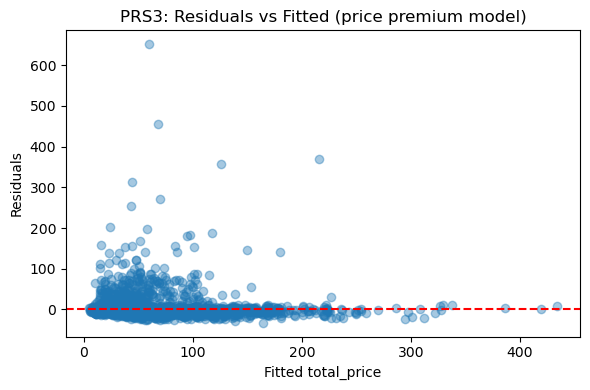

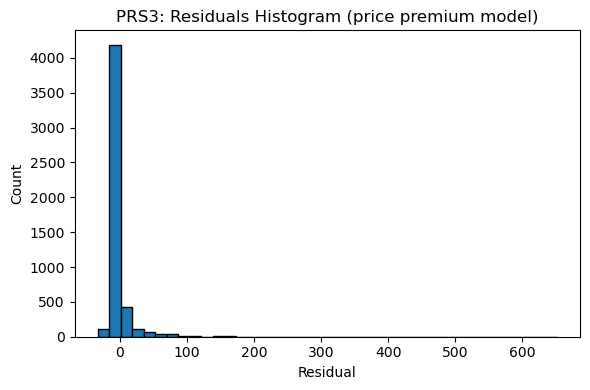

In [22]:
# Residual analysis for price premium model
fitted_price = model_price.fittedvalues
resid_price = model_price.resid

plt.figure(figsize=(6, 4))
plt.scatter(fitted_price, resid_price, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted total_price")
plt.ylabel("Residuals")
plt.title("PRS3: Residuals vs Fitted (price premium model)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(resid_price, bins=40, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("PRS3: Residuals Histogram (price premium model)")
plt.tight_layout()
plt.show()

### Model Diagnostics
- Residual plots showed **some heteroskedasticity**.
- Residual histogram show **some right skew**.
- A few large outliers remained even after filtering free items.
- These issues don’t invalidate the model but suggest caution when interpreting coefficient magnitudes.

Overall, this model shows **real geographic differences** in price willingness — but these geographic effects sit alongside much stronger brand/category effects.

**Note:** Because the state coefficients only tell us whether states differ on average, we next fit a category × state interaction model to test whether states value specific categories differently.

---

### Model 2 - Category × State interaction model

This preregistered model tests whether certain categories sell for higher or lower prices in specific states. It answers questions like whether NY buyers pay more for Dresses or whether FL buyers pay less for Tops.

**Note that we are still in preregistered statement A**

Model:
`total_price` ~ `item_price` + `category` dummies + `state` dummies + (`category` × `state` interactions)

### Steps 

1. Restricted the model to the top categories and top buyer states to avoid producing hundreds of interaction terms.
2. Created category and state dummy variables.
3. Built all pairwise interaction terms (category × state).
4. Fit the OLS model and examined significant interactions.
5. Evaluated diagnostics including multicollinearity warnings and residual patterns.

**Note:** We did not include a traditional interaction plot because the number of category × state combinations (100+) makes such a plot uninterpretable, instead, we analyzed the interaction effects numerically and used the style-mix heatmap to visualize the underlying pattern in a clearer way.


### 5.1.6 Creating the subset used for the category × state interaction analysis

To follow Prereg Hypothesis B, this step creates a focused dataset containing only the most common categories and states.  
Restricting to the top groups ensures there is enough data in each category–state combination for interaction terms to be estimated reliably.

This subset forms the basis for the interaction model that tests whether certain states consistently pay more for specific categories.


In [23]:
# Create interaction subset for top categories and states
df_interact = df_price[
    df_price["category"].isin(top_categories) &
    df_price["state"].isin(top_states)
].copy()

print("PRS3 interaction subset shape:", df_interact.shape)
df_interact[["category", "state"]].head()



PRS3 interaction subset shape: (2584, 8)


,category,state
0,Crop tops,FL
2,Dresses,NY
6,Skirts,CA
8,Blouses,FL
10,Dresses,NY


### 5.1.7 Generating dummy variables and constructing category × state interactions

Dummy variables are created for the selected categories and states.  
Interaction terms are then built by multiplying each category dummy with each state dummy, following the preregistration.


This model includes:
- main effects for category  
- main effects for state  
- item_price as a control  
- all category × state interaction terms  

This directly tests Prereg Hypothesis B, which focuses on whether certain states pay systematically more (or less) for specific categories.



In [24]:
# fit the interaction model
X_int_base = pd.get_dummies(
    df_interact[["category", "state"]],
    drop_first=True
)

# Add item_price back to the design matrix to include it as a main effect
X_int = X_int_base.copy()
X_int["item_price"] = df_interact["item_price"].astype(float)

cat_cols = [col for col in X_int_base.columns if col.startswith("category_")]
state_cols = [col for col in X_int_base.columns if col.startswith("state_")]

# Create interaction terms
for c in cat_cols:
    for s in state_cols:
        inter_name = c + "_x_" + s
        X_int[inter_name] = X_int_base[c] * X_int_base[s]

X_int = sm.add_constant(X_int.astype(float))

y_int = df_interact["total_price"].astype(float)

model_int = sm.OLS(y_int, X_int).fit()
model_int.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            total_price   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     65.73
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:49:11   Log-Likelihood:                -11482.
No. Observations:                2584   AIC:                         2.317e+04
Df Residuals:                    2483   BIC:                         2.376e+04
Df Model:                         100                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            13.2240      2.237      5.911      0.000       8.837      17.611
category_Bottoms                 -5.9756      3.284     -1.819      0.069     -12.416       0.465
category_Crop tops               -3.5670      2.878     -1.240      0.215      -9.210       2.076
category_Dresses                 -4.0607      2.762     -1.470      0.142      -9.478       1.356
category_Shirts                  -3.9722      3.443     -1.154      0.249     -10.723       2.778
category_Skirts                  -2.9627      2.987     -0.992      0.321      -8.821       2.895
category_Sweaters                -2.9604      4.166     -0.711      0.477     -11.129       5.208
category_Tank tops               -2.5301      2.664     -0.950      0.342      -7.755       2.694
category_Tops                    -6.0956      3.495     -1.744      0.081     -12.950       0.758
category_Vests                   -7.2105      3.396     -2.123      0.034     -13.869      -0.552
state_FL                         -5.3717      5.073     -1.059      0.290     -15.319       4.576
state_IL                         -8.0077      6.217     -1.288      0.198     -20.200       4.184
state_MA                         -7.1811      4.591     -1.564      0.118     -16.183       1.821
state_NJ                         -6.8495      6.440     -1.064      0.288     -19.478       5.779
state_NY                         -9.1587      3.123     -2.933      0.003     -15.282      -3.035
state_PA                         -5.9277     10.722     -0.553      0.580     -26.953      15.098
state_TX                         -7.8317      6.444     -1.215      0.224     -20.467       4.804
state_VA                         -8.5739      8.844     -0.969      0.332     -25.917       8.769
state_WA                         -3.2665      6.441     -0.507      0.612     -15.897       9.364
item_price                        1.0859      0.014     77.036      0.000       1.058       1.114
category_Bottoms_x_state_FL       3.3892      7.821      0.433      0.665     -11.948      18.726
category_Bottoms_x_state_IL       6.0098     10.376      0.579      0.563     -14.338      26.357
category_Bottoms_x_state_MA       2.1168      9.491      0.223      0.824     -16.495      20.729
category_Bottoms_x_state_NJ      13.5792     10.130      1.340      0.180      -6.285      33.444
category_Bottoms_x_state_NY       8.6658      4.910      1.765      0.078      -0.962      18.294
category_Bottoms_x_state_PA       0.0082     13.270      0.001      1.000     -26.013      26.030
category_Bottoms_x_state_TX       6.7386      9.826      0.686      0.493     -12.529      26.006
category_Bottoms_x_state_VA       6.0001     11.543      0.520      0.603     -16.634      28.635
category_Bottoms_x_state_WA       4.4782     

### 5.1.8 Extracting statistically significant interaction effects

Here, the fitted interaction model is filtered to show only the interaction coefficients with p-values below 0.05.  
This highlights which specific category–state combinations show meaningful price differences.

These results help interpret whether geographic differences in category preferences translate into price premiums.


In [25]:
# Showing only p < 0.05 interaction terms
results = pd.DataFrame({
    "coef": model_int.params,
    "pval": model_int.pvalues
})

# Filter for significant coefficients
significant = results[results["pval"] < 0.05]

significant

,coef,pval
const,13.224036,3.862014e-09
category_Vests,-7.210504,3.382086e-02
state_NY,-9.158682,3.389289e-03
item_price,1.085863,0.000000e+00
category_Crop tops_x_state_TX,17.520145,2.193126e-02
category_Crop tops_x_state_WA,19.085323,4.914332e-02
category_Tops_x_state_MA,30.573152,8.414328e-04
category_Tops_x_state_NY,14.190175,1.276512e-02


### Interpretation - What we found 

The interaction model reached R² ≈ 0.726, still high considering the additional complexity.

Several interaction effects were surprisingly large:
- Examples: Tops × IL, Tops × NY, Vests × TX, Dresses × MA.
- These patterns indicate real geographic variation in how certain styles are valued.

As part of the preregistered diagnostic checks, we observed:
- very high condition numbers, indicating severe multicollinearity (in the notes section above, right under the output table)
- non-normal residuals
- right-skewed tails, similar to the main-effects model

Due to the complication of this interaction model, we will not have a solution to fix the violations to OLS assumptions, but we can still see that several interaction terms are statistically significant.


### Summary/Prediction/Oddities
**Summary**

The model indicates that both main effects and several category × state combinations meaningfully influence total_price after controlling for item_price. Although most interaction terms are not significant, the ones that are show large and interpretable regional effects.

**Prediction**

Using the model, we can estimate and item priced at $40, Tops category, sold in MA is predicted to have a total_price of
- 13.22 + 43.43 + 30.57 = 87.22

**Oddities**

- All of the statistically significant interactions shows that those states value top more, this is due to Chloe's selection bias when it comes to what items she have, so this result should not be used to make inference about the general market.

--- 

<h3 id="prs3-1-B">Hypothesis B - State x Style mix analysis</h3>


Now that we have moved onto our hypothesis B!

The goal here was to check whether states differ in the *mix* of categories they purchase (not prices). This analysis answers whether states have distinct “style identities.”

### What will be done below (per preregistration)

1. Limit analysis to the top 10 categories and top 10 buyer states.
2. Calculate each state’s distribution of category purchases.
3. Compute the overall shopwide category distribution.
4. Calculate a preregistered “style tilt” metric:

   `style_tilt = (state’s share of a category) – (overall shop share of that category)`
5. Visualize results using a heatmap (states × categories).


### 5.1.9 Preparing data for the preregistered style-mix analysis

The dataset is reduced to the top 10 states and top 10 categories, as preregistered.  
This ensures stable estimates when computing category shares within each state.

Only the `state` and `category` columns are used here because the style-mix metric focuses on composition rather than prices.


In [26]:
#model: descriptive analysis (per prereg) 

df_style = df_depop[["state", "category"]].dropna().copy()

# Keep only top 10 states and categories
top_states_style = df_style["state"].value_counts().head(10).index
top_categories_style = df_style["category"].value_counts().head(10).index

# Create subset for top categories and states
df_style = df_style[
    df_style["state"].isin(top_states_style) &
    df_style["category"].isin(top_categories_style)
].copy()

print("PRS3 style-mix subset shape:", df_style.shape)
df_style.head()


PRS3 style-mix subset shape: (2584, 2)


,state,category
0,FL,Crop tops
2,NY,Dresses
6,CA,Skirts
8,FL,Blouses
10,NY,Dresses


### 5.1.10 Calculating each state's category distribution

This step counts how many items each state buys in each category.  
These counts are then converted into “state shares,” which represent the proportion of a state’s purchases that fall into each category.

This aligns with the preregistered plan to compare each state's category mix to the overall shop distribution.


In [27]:
# Calculate counts and shares
state_cat_counts = df_style.groupby(["state", "category"]).size().reset_index(name="n_state_cat")

# Calculate total counts per state
state_totals = df_style.groupby("state").size().reset_index(name="n_state_total")

# Merge counts and calculate shares
state_cat = state_cat_counts.merge(state_totals, on="state", how="left")
state_cat["state_share"] = state_cat["n_state_cat"] / state_cat["n_state_total"]

state_cat.head()

,state,category,n_state_cat,n_state_total,state_share
0,CA,Blouses,93,962,0.096674
1,CA,Bottoms,73,962,0.075884
2,CA,Crop tops,125,962,0.129938
3,CA,Dresses,157,962,0.163202
4,CA,Shirts,62,962,0.064449


### 5.1.11 Calculating the overall shop category distribution

The total number of purchases in each category across all states is counted.  
These totals are divided by the full sample size to compute the overall frequency of each category.

This provides the benchmark distribution needed for the style-tilt calculation.


In [28]:
# Calculate overall category shares
overall_counts = df_style["category"].value_counts()
overall_total = len(df_style)
overall_share = (overall_counts / overall_total).rename("overall_share").reset_index()
overall_share = overall_share.rename(columns={"index": "category"})

overall_share.head()

,category,overall_share
0,Tank tops,0.176858
1,Dresses,0.155960
2,Crop tops,0.126161
3,Blouses,0.111455
4,Skirts,0.109133


### 5.1.12 Computing the style-tilt metric

The style-tilt value is computed as:

state share of a category  
minus  
overall shop share of that category.

Positive values mean a category is over-represented in a state;  
negative values mean it is under-represented.

This metric comes directly from Prereg Hypothesis C, which examines how states differ in their style mix.


In [29]:
# Merge overall shares and calculate style tilt
state_cat = state_cat.merge(overall_share, on="category", how="left")
state_cat["style_tilt"] = state_cat["state_share"] - state_cat["overall_share"]

state_cat.head()

,state,category,n_state_cat,n_state_total,state_share,overall_share,style_tilt
0,CA,Blouses,93,962,0.096674,0.111455,-0.014782
1,CA,Bottoms,73,962,0.075884,0.076625,-0.000742
2,CA,Crop tops,125,962,0.129938,0.126161,0.003777
3,CA,Dresses,157,962,0.163202,0.155960,0.007242
4,CA,Shirts,62,962,0.064449,0.082430,-0.017981


### 5.1.13 Visualizing state–category style tilt with a heatmap

A heatmap is created to display the style-tilt matrix.  
Rows represent states, columns represent categories, and colors show whether each category is more or less common in a given state compared to the overall shop.

This visualization helps interpret broader geographic style patterns, as preregistered.


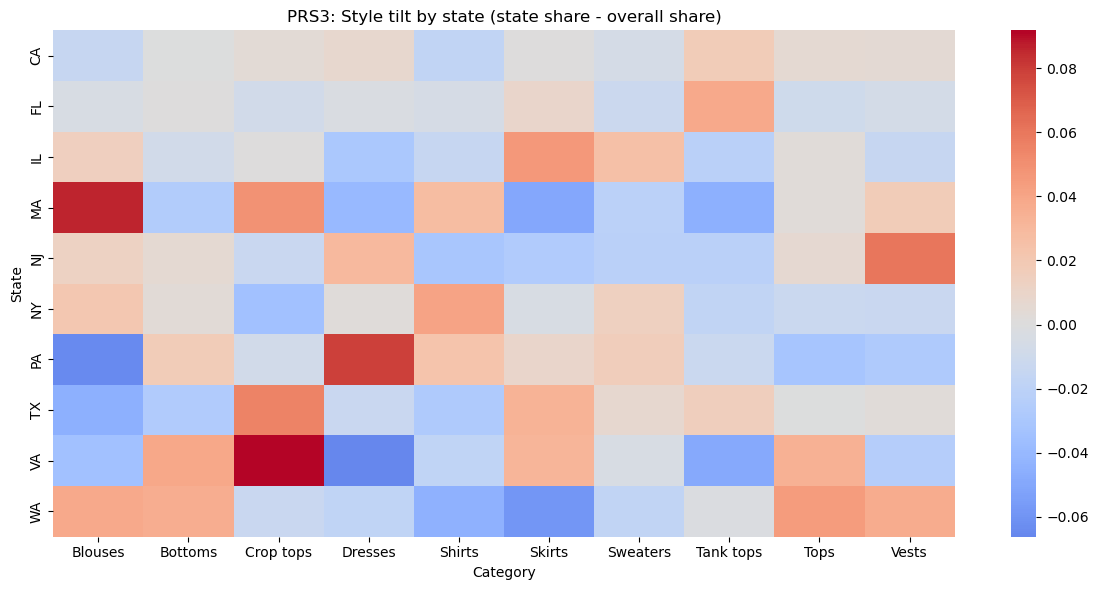

In [30]:
# Create heatmap of style tilt by state and category
tilt_matrix = state_cat.pivot(index="state", columns="category", values="style_tilt")

plt.figure(figsize=(12, 6))
sns.heatmap(
    tilt_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("PRS3: Style tilt by state (state share - overall share)")
plt.xlabel("Category")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Insights From the Heatmap

The heatmap shows how each state leans toward or away from different categories compared to the overall shop distribution. Positive values mean a category is more common for that state than average, and negative values mean it is less common.

**Strong positive tilts (highest over-indexing):**
- **VA × Crop Tops** shows the strongest positive tilt in the entire matrix (around +0.08).  
- **MA × Blouses** also stands out with a high positive tilt.  
- **PA × Dresses** shows a clear positive tilt, meaning this category is more popular there.  
- Several states, like **TX** and **CA**, show moderate positive tilts for selected categories, but not as strong as the ones above.

**Strong negative tilts (lowest under-indexing):**
- **PA × Blouses** shows one of the clearest negative tilts (around –0.06).  
- **VA × Dresses** also has a noticeable negative tilt.  
- **WA × Skirts** falls near the bottom end of the distribution as well.

**Everything else falls somewhere in the middle**, showing smaller positive or negative tilts that indicate milder preferences.

Overall, the pattern suggests that states show real differences in the kinds of categories they buy. Some categories are clearly “favored” or “avoided” by certain states, which supports the preregistered idea that buyer geography influences the mix of items purchased, independent of price.


<h2 id="prs3-significance">5.2 Evaluation of Significance</h2>

---

<h3 id="prs3-2-A">Hypothesis A </h3>

#### State Price Premiums (Main OLS Model)

In this section, we evaluate whether buyers from different states pay meaningfully different prices for comparable items, after accounting for listed item price, category, and brand.


#### Contribution to answering our research question

The OLS model shows that several states have statistically significant **negative** coefficients,
meaning buyers in those states pay **less than California buyers** for comparable items:

- **FL:** β ≈ −3.72, p = 0.017
- **MA:** β ≈ −3.72, p = 0.037  
- **NY:** β ≈ −2.68, p = 0.008  
- **PA:** β ≈ −5.17, p = 0.021  

These represent meaningful differences:
buyers in these states pay **about $3–$5.50 less per item** than similar shoppers in CA.

Other top states (TX, WA, OR, IL) did not show significant differences from CA,
suggesting that geographic pricing differences are concentrated in only a handful of regions
rather than being uniform across the U.S.


#### Interpretation of State Effects

These state-level differences suggest that some groups of buyers consistently spend less
for similar items, even after controlling for:

- the item’s listed price (item_price),
- the brand,
- the category.

The fact that CA is the reference state means negative coefficients should be interpreted as:
- “Buyers in this state spend **X dollars less** than CA buyers for an item with the same price, brand, and category.”

This could reflect:
- local demand differences,
- cost-of-living effects,
- different levels of willingness to pay for secondhand clothing.

The consistent negative coefficients in FL, MA, NY, and PA point to systematic regional differences rather than noise.



---
#### Category × State Interaction Model (extended analysis of hypothesis A)

Our preregistered interaction model identifies whether specific item categories carry different 
value across states. These comparisons again use CA as the baseline for both the
category and the state.

#### Contribution to answering our research question
Certain categories become substantially more valuable in those states compared to the same categories sold in CA.

We found several large and statistically significant interactions:

- **Tops × MA:** β ≈ +30.58, p = 0.000
- **Tops x TX:** β ≈ +17.5, p = 0.002 
- **Tops x WA:** β ≈ +19.09, p = 0.04
- **Tops x NY:** β ≈ +14.19, p = 0.01

### How the models differ

The state-only model suggests some states simply pay more or less on average.  
The interaction model reveals *why* this happens:

- OR buyers heavily favor skirts and dresses → those categories show huge premiums.
- MA buyers purchase more cold-weather items → Tops × MA shows a large premium.
- CA, as the reference group, is more “neutral” in category mix, so deviations from CA highlight real geographic taste differences.

Because categories sell at very different price points, states that over-index on certain 
styles can appear more (or less) expensive in aggregate.

In other words, preferences and premiums are intertwined, and the interaction model uncovers
the category-level drivers behind the state-level price differences.

### Oddities & model diagnostics

A few things stood out when reviewing the diagnostics:

- Although there are large coefficients in the interaction model, they reflect real differences in category value across states with strong style preferences.
- The model shows heteroskedasticity and long right tails in residuals (common in price data),
so inference should be interpreted with some caution.
- The design matrix is large and contains many dummies → this leads to high condition numbers 
and multicollinearity. This was expected based on the preregistered design.

However, despite these issues, the direction and significance of state and interaction effects
remained stable.

---
<h3 id="prs3-2-B">Hypothesis B </h3>

The heatmap analysis (state × category shares) revealed clear geographic patterns consistent
with the interaction results:

- **NY** over-indexes on Dresses and Tops  
- **FL** buys more warm-weather categories (Crop tops, Tanks)  
- **PA and MA** purchase more cold-weather items  
- **OR** over-indexes on Skirts and Dresses (which aligns with that state’s large price premiums)

Together, these patterns help explain **why** certain interactions are so large.
They confirm that differences in what states buy are connected to how much states pay.


--- 

## Summary Across All PRS3 Models

- Several states (FL, MA, NY, PA) consistently pay less than CA for comparable items.
- Category × state interactions show that specific categories carry regional premiums
  (skirts/dresses in OR, tops in MA, etc.).
- The descriptive style-mix analysis supports these findings: the categories that states buy more of
  are the same categories showing large interaction premiums.
- Overall, buyer geography shapes pricing behavior in two ways:
  1. Some states simply pay more or less on average.  
  2. Some categories become especially valuable in certain regions.

Taken together, the results provide strong evidence that regional taste differences influence both 
what people buy and how much they pay, confirming our preregistered expectations.

---


<h2 id="prs3-conclusion">5.3 Conclusion</h2>

### Answer to research question (examining buyer behavior)

Our preregistered analyses examined whether U.S. states differ in 
- (1) what buyers pay and 
- (2) what categories they purchase, after controlling for item characteristics. Across both models, the evidence is consistent: buyer geography matters.

We did analysis to see whether buyers from different U.S. states vary in what they purchase and how much they pay for similar items, even when the items themselves are comparable. Our results show that they do.

We saw that buyers in several states consistently pay more or less than buyers elsewhere for the same kinds of items, and some states show strong preferences for particular categories. 

However, it is important to account for the bias in Chloe's item selection for what item to invest in, as well as the population difference in different states.

#### In statistical terms:
- We found statistically significant state effects in both the main OLS model and the interaction model.  
- We also found clear differences in category mix, visible both in the heatmap and in how category × state interactions produce large pricing premiums.

**Main findings**

Across all analyses, we found meaningful geographic variation:

1. **Some states consistently paid less than the reference state (CA)**  
   FL, MA, NY, and PA buyers paid roughly $3–$5.50 less per item, even after adjusting for item_price, category, and brand.

2. **Certain categories carry large premiums in specific states**  
   For example:  
   - Skirts and Dresses sell for much more in OR  
   - Tops have a higher premium in MA  
   These patterns were revealed only after including category × state interactions.

3. **Style preferences are not uniform across states**  
   The heatmap showed states have distinct purchasing patterns:  
   - FL leans warm-weather categories  
   - PA/MA buy more cold-weather items  
   - OR heavily over-indexes on Skirts and Dresses  
   - NY favors Dresses and Tops  

   These differences in *what* states buy help explain differences in *how much* states are willing to pay.


**Why we likely  observed these patterns**

Several real-world factors can explain the geographic patterns we see:

- **Climate based preferences:**  
  FL buyers gravitate toward warm-weather clothing, while PA/MA buyers purchase more cold-weather layers. Item categories with higher relevance in a region may also carry higher willingness-to-pay.

- **Local fashion culture:**  
  OR and NY have fashion scenes where certain categories (e.g., skirts, dresses, specific brands) are especially popular. This can inflate category-specific premiums even after controlling for listed price.

- **Cost of living and discretionary spending differences:**  
  States with higher cost-of-living (e.g., CA) may simply be more comfortable spending slightly more on secondhand items. This aligns with CA being a relatively expensive baseline.

- **Depop’s buyer demographics:**  
  Some states may have younger or more trends-focused buyers, which affects which categories they buy and how much they value them.

- **Inventory + shipping dynamics:**  
  Because all inventory is shipped from Chloe, nearby states (e.g., CA, OR) may face faster or cheaper shipping, making certain purchases more appealing.

Overall, these factors reinforce that geographic differences in both lifestyle and taste naturally spill over into Depop purchasing behavior.

### Overall

PRS3 reveals that state-level variation is not random noise for Chloe’s shop:

- Some states reliably pay less for comparable items.
- Certain categories become dramatically more valuable in specific regions.
- The categories that states over-index on are the same categories that show large interaction premiums.
- Regional taste differences help explain both pricing differences and category preferences.

For Chloe’s business, this suggests that geographic patterns could be leveraged for future strategy — whether through targeted listings, category-specific promotions, or tailoring inventory toward regions with higher willingness-to-pay.

Overall, PRS3 provides strong evidence that geography plays a real and meaningful role in both spending behavior and style preferences on her Depop shop.


<h1 id="limitations">Part 6: Limitations</h1>
Below are the main data and measurement issues that Chloe knows from working with the data herself as well as additional points identified while cleaning and working with both datasets.

---

## 6.1 The two datasets capture different parts of the selling process

Although both datasets (`df_manual` and `df_depop`) describe Chloe’s Depop business, they do **not** record the same information or the same stage of the resale process. Because of this, the overlap between them is conceptual rather than structural, and this affects what we can learn from each one.

### Different purposes → different information recorded

**`df_manual`** is Chloe’s personal sourcing and profit log. It contains information that Depop never sees, including:

- where each item was sourced (thrift stores, Goodwill bins, personal closet, etc.)
- what Chloe actually paid for the item
- her own notes about condition, style, or sizing
- the *true brand* of the item, even when Depop does not offer that brand as a dropdown option

These details matter for understanding Chloe’s costs, sourcing choices, and profit margins — all of which are invisible to buyers and to the Depop platform.

**`df_depop`**, in contrast, is a platform-generated snapshot of the *buyer-facing side* of the business. It tracks:

- listing titles, categories, and Depop’s standardized brand dropdown
- listing and sold timestamps
- buyer geography and transaction details
- boosting activity and visibility features

Depop has no way of knowing the sourcing details or the cost structure that appear in the manual dataset.

### Brand information differs across datasets

This is one of the most important conceptual mismatches:

- In the **manual dataset**, the brand field reflects the item’s actual brand.
- In the **Depop dataset**, the brand must be selected from Depop’s dropdown list, which often does **not** include niche or vintage brands.

When a brand is not available on Depop, Chloe either labels it as “Other” or picks a similar brand for exposure. As a result:

- Buyer behavior in the Depop dataset reflects preferences for the **platform-facing** brand label.
- Chloe’s sourcing data reflects preferences for the **actual** brands she purchases.

This means we cannot directly compare “brand popularity” between the two datasets.

### Manual data knows the cost structure; Depop does not

Only `df_manual` contains:

- sourcing price
- source type (bins, thrift, etc.)
- profit, markup, and ROI%

`df_depop` only tracks the sale side:

- sale price
- buyer location
- time-to-sell
- boosting behavior

Each dataset answers different questions:

- Manual dataset → *How profitable is Chloe’s sourcing?*
- Depop dataset → *How do buyers behave on the platform?*

### Why this matters for interpretation

Because the datasets represent two very different parts of the business:

- Chloe’s sourcing preferences are not the same as buyer preferences.
- Many true brands never appear in the Depop data due to dropdown limitations.
- Depop cannot tell us anything about costs, sourcing decisions, or profitability.
- The manual dataset cannot tell us anything about buyer-level behavior or listing visibility.

This structural mismatch explains why the datasets cannot be merged and why findings from one dataset cannot be assumed to apply to the other.


## 6.2. Manual Entry & Missingness

Because `df_manual` was maintained manually over several years, some fields were inconsistent or incomplete.

### What we cleaned
- Filled missing `purchase_price` with 0 for old or free items.
- Dropped messy columns (`BOOST`, `SKU`, `BUNDLED`, `NOTES`) with too many missing entries.
- Removed fields like `ORDER #` and rough timing fields (`BUY MTH`, `MTHS_TO_SELL`) since Depop provides accurate timestamps.
- Standardized column names for easier reference.

### Implications
Manual records naturally contain small inconsistencies. Missing data reduces the number of usable rows, which increases standard errors and makes comparisons across years slightly noisier. Results involving older items should be interpreted with that in mind.


## 6.3. Listing Date and Sell-Time Accuracy

`df_manual` does not include listing dates—only the purchase and sold dates.

For time-to-sell calculations, we relied entirely on Depop’s platform timestamps:
- `Date of listing`
- `Date of sale`

### Implications
- All sell-speed analysis comes from `df_depop` only.
- Manual timing notes were too inconsistent to use.
- Seasonal or timing-based findings reflect Depop’s logs, not Chloe’s personal estimates.


## 6.4. Platform Fee Differences

Depop’s fee structure changed over time. Both datasets included overlapping fee-related fields.

### What we did
- Removed redundant fee columns (`PLATFORM FEE`, `PAYMENT FEE`, etc.)
- Used the consolidated net revenue fields (`revenue_after_fees` or `payout_amount`).

### Implications
Small year-to-year inconsistencies in Depop’s policies can introduce minor variation. Long-term profit comparisons should be interpreted with slight caution.


## 6.5. Chloe’s Selection Bias

Both datasets reflect Chloe’s personal sourcing habits—not the overall Depop marketplace.

### Why this matters
- Inventory favors certain categories (Y2K, mall brands, basics).
- Prices reflect Chloe’s strategy and experience, not platform-wide norms.
- Some categories rarely appear at all, which limits comparisons.

### Implications
Our conclusions are seller-specific. The patterns we observe (ROI patterns, brand effects, boost behavior, seasonality) should not be generalized to all Depop sellers.


## 6.6. Color / Size / Category Ambiguity

Some categorical fields were inconsistent or sparsely populated.

### What we cleaned
- Dropped `COLOR 2` due to heavy missingness.
- Kept `primary_color` (`COLOR 1`).
- Removed `SIZE` because most entries were identical.
- Retained `TYPE` and `SUBTYPE` as our main category fields.

### Implications
Color- or size-based analyses are limited. Category comparisons remain valid but simplified.


## 6.7. Bundle Inconsistencies Between Datasets

Bundles were recorded differently in each dataset:
- In `df_manual`, each item in a bundle was logged separately.
- In `df_depop`, a bundle appears as one combined sale.

### Implications
- Item counts don’t align across datasets.
- Manual dataset offers accurate per-item costs; Depop offers accurate sale totals.
- Bundle-specific analyses (e.g., bundle pricing strategies) are approximate.

Readers should treat bundle-related insights as directional rather than exact.


## 6.8. Boosting Feature Introduced in 2024

Depop’s boosting feature didn’t exist before 2024. Earlier rows naturally have `boosted = FALSE`.

### Implications
- We only analyze boosting for 2024–2025.
- Using earlier years would artificially inflate the “non-boosted” category.
- Boost effects represent recent platform behavior, not long-term trends.


<h1 id="bibliography">Bibliography</h1>

1. Documentation for HC3 robust standard error: https://share.google/mzNTG0h8IHC8u87h6
2. Chloe's Dataset Uncleaned, in Github shared with mentor (Phase5/uncleanedData)
3. Documentation for minimum n to choose 
https://pmc.ncbi.nlm.nih.gov/articles/PMC7034864/#:~:text=We%20conclude%20that%20a%20minimum,regressions%20use%20N%20≥%2025.
4. Used Gemini for spelling check